# ACC2125 Group Project — Sydney Short-Term Rentals and Rail Access

**Group:** GroupXX
**City / snapshot:** Sydney, New South Wales, Australia — Inside Airbnb snapshot scraped 17–29 June 2026 (main sample) and 21 March 2026 (cross-season check)
**External datasets** (all CC BY 4.0 or ODbL, see `README.md` for full citations):

| File | Source | Used for |
|---|---|---|
| `External01_GroupXX.csv` | Transport for NSW, *Timetables Complete GTFS* (timetable from 6 Oct 2026) | Station entrances, mode, rail travel time to the CBD and airport, service frequency |
| `External02_GroupXX.csv` | Transport for NSW, *Train, Metro and Light Rail Station Entries and Exits* (Oct 2024 – Aug 2026) | Station patronage |
| `External03_GroupXX.csv` | Australian Bureau of Statistics, *SEIFA 2021* by Statistical Area Level 2 (SA2) | Neighbourhood socio-economic advantage; SA2 areas for fine location controls |
| `External04_GroupXX.csv` | OpenStreetMap contributors (Overpass API), beaches and tourist attractions | Distance to the nearest beach, attractions within 1 km |
| `External05_GroupXX.csv` | Transport for NSW, *Train station entrance locations* (2020, v4) | Sensitivity check: what the 2020 network misses |

Supporting geometry (not submitted as data files): ABS ASGS Edition 3 SA2 boundaries (2021, GDA2020) and the OpenStreetMap pedestrian network, used only to assign SA2 codes and to measure walking distances.

This notebook reproduces every number, table and figure used in `Report_GroupXX.docx` and `Slides_GroupXX.pptx`. Run it top to bottom from the project folder. Figures are written to `figures/` at 300 DPI and headline numbers to `outputs/results.json`.

Structure:
- **Part A1** – data selection, external-data integration and the Data Decisions Log
- **Part A2** – guided questions Q1–Q3
- **Part A3** – two unguided analyses (does rail access pay; multi-listing hosts)
- **Part B** – three machine learning models (Ridge regression, K-Means, XGBoost + SHAP)

In [1]:
# ---- Imports and global settings ----
import json, re, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import geopandas as gpd
from scipy import stats
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra
from sklearn.neighbors import BallTree
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrix, build_design_matrices
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

DATA = Path("data")                         # raw Inside Airbnb files and supporting geometry (not submitted)
GTFS = Path("tfNSW GTFS")                   # raw TfNSW GTFS feed (1.4 GB, not submitted; External01 is derived from it)
EXT = {i: Path(f"External0{i}_GroupXX.csv") for i in range(1, 6)}
FIG = Path("figures"); FIG.mkdir(exist_ok=True)
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
SEED = 42
RESULTS = {}                                # headline numbers exported for the report and slides

# Chart palette: validated categorical slots 1-3, a blue sequential ramp and recessive chrome
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
BLUE_RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]   # ordinal steps 250-650
BLUES = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#6da7ec", "#2a78d6", "#184f95", "#0d366b"])
ORANGES = LinearSegmentedColormap.from_list("oranges", ["#fde3d6", "#f4a07a", "#eb6834", "#b8461a", "#7a2c0c"])

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": SURFACE, "savefig.facecolor": "white",
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.6, "axes.labelcolor": INK2,
    "axes.titlecolor": INK, "axes.titlesize": 10, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.5, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK2, "ytick.color": INK2, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "font.family": "DejaVu Sans", "font.size": 9, "legend.frameon": False,
    "legend.fontsize": 8, "lines.linewidth": 2,
})

def savefig(fig, name):
    """Save a figure at 300 DPI for the report and slides."""
    fig.savefig(FIG / f"{name}.png", dpi=300, bbox_inches="tight")
    plt.show()

def pct(x, d=1):
    return round(100 * float(x), d)

def md(text):
    """Render findings text with every number filled in from the computed results."""
    display(Markdown(text))

def ci_txt(lo, hi, unit="%", d=1):
    return f"95% CI {lo:+.{d}f}{unit} to {hi:+.{d}f}{unit}"

def p_txt(p):
    return "p < 0.001" if p < 0.001 else (f"p = {p:.3f}" if p < 0.01 else f"p = {p:.2f}")

def fit(formula, data, family=None, cluster="host_id"):
    """OLS (or GLM) with standard errors clustered by host: a host's listings are not independent observations."""
    model = smf.ols(formula, data) if family is None else smf.glm(formula, data, family=family)
    groups = pd.factorize(data.loc[model.data.row_labels, cluster])[0]
    return model.fit(cov_type="cluster", cov_kwds={"groups": groups})

EARTH_R = 6_371_000  # metres
TOWN_HALL = (-33.8731, 151.2065)
WALK_M_PER_MIN = 80

def haversine_m(lat, lon, lat0, lon0):
    lat, lon, lat0, lon0 = map(np.radians, [lat, lon, lat0, lon0])
    a = np.sin((lat - lat0) / 2) ** 2 + np.cos(lat) * np.cos(lat0) * np.sin((lon - lon0) / 2) ** 2
    return 2 * EARTH_R * np.arcsin(np.sqrt(a))

def station_key(s):
    """Normalise station names across TfNSW files ('Central  Station', 'Central Station', 'Central')."""
    return (s.str.replace(r"\s+", " ", regex=True).str.strip().str.lower()
             .str.replace(r" (station|light rail|lr)$", "", regex=True))

## Part A1 – Data selection and integration

### A1.1 Load the raw data
The Sydney snapshot gives a large, mature market (20,000+ listings) with strong commuter-rail coverage, which makes it a good setting to test whether rail access shows up in prices and demand. The June 2026 snapshot is the main sample. The March 2026 snapshot is used only to check whether the rail result holds in a different season (the September and December 2025 snapshots on Inside Airbnb have no prices, so they cannot be used).

In [2]:
listings_raw = pd.read_csv(DATA / "listings.csv.gz")
calendar_raw = pd.read_csv(DATA / "calendar.csv.gz", parse_dates=["date"])
lga_shapes = gpd.read_file(DATA / "neighbourhoods.geojson")
listings_mar = pd.read_csv(DATA / "snapshots" / "listings_2026-03-21.csv.gz")

SNAPSHOT = pd.to_datetime(listings_raw["last_scraped"]).max()
summary = pd.DataFrame({
    "Dataset": ["listings.csv.gz (Jun 2026)", "calendar.csv.gz", "neighbourhoods.geojson", "listings.csv.gz (Mar 2026)"],
    "Source": ["Inside Airbnb"] * 4,
    "Rows": [len(listings_raw), len(calendar_raw), len(lga_shapes), len(listings_mar)],
    "Columns": [listings_raw.shape[1], calendar_raw.shape[1], lga_shapes.shape[1], listings_mar.shape[1]],
})
print("Snapshot date:", SNAPSHOT.date())
print("Calendar covers", calendar_raw["date"].min().date(), "to", calendar_raw["date"].max().date())
RESULTS["snapshot"] = str(SNAPSHOT.date())
RESULTS["snapshot_start"] = str(pd.to_datetime(listings_raw["last_scraped"]).min().date())
RESULTS["snapshot_mar"] = str(pd.to_datetime(listings_mar["last_scraped"]).max().date())
RESULTS["raw_listings"] = len(listings_raw)
RESULTS["raw_listings_mar"] = len(listings_mar)
RESULTS["raw_calendar_rows"] = len(calendar_raw)
summary

Snapshot date: 2026-06-29
Calendar covers 2026-06-17 to 2027-06-28


,Dataset,Source,Rows,Columns
0,listings.csv.gz (Jun 2026),Inside Airbnb,20573,90
1,calendar.csv.gz,Inside Airbnb,7509145,5
2,neighbourhoods.geojson,Inside Airbnb,38,3
3,listings.csv.gz (Mar 2026),Inside Airbnb,13563,90


### A1.2 Cleaning the listings and recording every decision
Each step below appends a row to the **Data Decisions Log** (Change Details / Reason and Justification), so the log always matches what the code actually did. The same cleaning function is applied, without logging, to the March snapshot.

In [3]:
LOG = []
def log(change, reason):
    LOG.append({"Change Details": change, "Reason and Justification": reason})

def parse_bath(text):
    if pd.isna(text):
        return np.nan
    text = text.lower()
    if "half" in text:
        return 0.5
    m = re.search(r"\d+(\.\d+)?", text)
    return float(m.group()) if m else np.nan

def clean_listings(raw, log=lambda *a: None):
    df = raw.copy()
    # 1. Remove columns that are completely empty in this snapshot
    empty_cols = df.columns[df.isna().all()].tolist()
    df = df.drop(columns=empty_cols)
    log(f"Dropped {len(empty_cols)} columns that are 100% empty (e.g. host_since, host_response_rate, instant_bookable).",
        "These fields are not populated in the June 2026 Sydney snapshot, so they carry no information.")

    # 2. Convert price text ("$1,234.00") to a number and drop listings without a price
    df["price"] = df["price"].astype(str).str.replace(r"[$,]", "", regex=True).replace("nan", np.nan).astype(float)
    n_before = len(df)
    df = df[df["price"].notna()]
    log(f"Removed {n_before - len(df):,} listings with no nightly price ({len(df):,} remain).",
        "Price is the key outcome for Q2, Q3, A3 and all models. Listings without a price are mostly unbookable or inactive.")

    # 3. Keep short-term listings only
    n_before = len(df)
    df = df[df["minimum_nights"] <= 30]
    log(f"Removed {n_before - len(df):,} listings with minimum stay above 30 nights ({len(df):,} remain).",
        "These are mid/long-term rentals (most require 90+ nights). They price and book differently from short-term stays.")

    # 4. Trim extreme prices (1st and 99th percentile)
    p_lo, p_hi = df["price"].quantile([0.01, 0.99])
    n_before = len(df)
    df = df[df["price"].between(p_lo, p_hi)]
    log(f"Removed {n_before - len(df):,} listings priced below ${p_lo:,.0f} or above ${p_hi:,.0f} per night (1st/99th percentiles).",
        "The raw maximum was over $50,000 a night, which looks like data entry errors or placeholder prices. Trimming stops a few points dominating means and regressions.")

    # 5. Bathrooms: fill missing numeric values from the text field and flag shared bathrooms
    n_missing_bath = int(df["bathrooms"].isna().sum())
    df["bathrooms"] = df["bathrooms"].fillna(df["bathrooms_text"].map(parse_bath))
    df["bath_shared"] = df["bathrooms_text"].str.contains("shared", case=False, na=False).astype(int)
    log(f"Filled {n_missing_bath:,} missing bathroom counts by parsing bathrooms_text; added a shared-bathroom flag.",
        "The text field holds the same information (e.g. '1.5 shared baths'), so parsing recovers values without guessing.")

    # 6. Impute remaining structural gaps with the median for the same room type and guest capacity
    struct = ["bedrooms", "beds", "bathrooms"]
    n_missing = {c: int(df[c].isna().sum()) for c in struct}
    for c in struct:
        df[c] = df[c].fillna(df.groupby(["room_type", "accommodates"])[c].transform("median"))
        df[c] = df[c].fillna(df[c].median())
    log("Imputed missing bedrooms ({bedrooms:,}), beds ({beds:,}) and bathrooms ({bathrooms:,}) with the median of listings with the same room type and capacity.".format(**n_missing),
        "Guest capacity strongly predicts room counts. A grouped median keeps imputed values realistic and avoids dropping listings.")

    # 7. Engineer simple listing features
    df["amenities_count"] = df["amenities"].map(lambda s: len(json.loads(s)) if isinstance(s, str) else 0)
    df["superhost"] = (df["host_is_superhost"] == "t").astype(int)
    top_types = df["property_type"].value_counts().head(6).index
    df["property_group"] = np.where(df["property_type"].isin(top_types), df["property_type"], "Other")
    df["host_tier"] = pd.cut(df["calculated_host_listings_count"], [0, 1, 9, np.inf],
                             labels=["Single (1)", "Small multi (2-9)", "Commercial (10+)"])
    df["rated"] = df["number_of_reviews"] >= 5
    log("Created amenities_count, superhost flag, property_group (top 6 types + Other), host_tier (1 / 2-9 / 10+ listings) and a 'rated' flag (5+ reviews).",
        "These turn raw text and long-tail categories into variables the analysis and models can use. With fewer than 5 reviews a rating is too noisy to compare.")
    log("Kept review-score gaps as missing (not imputed) for EDA; rating analyses use listings with 5+ reviews only.",
        f"{pct(df['review_scores_rating'].isna().mean())}% of listings have no rating because they have no reviews. Filling these in would invent guest opinions.")
    return df.reset_index(drop=True), (p_lo, p_hi)

df, (p_lo, p_hi) = clean_listings(listings_raw, log)
df_mar, _ = clean_listings(listings_mar)
print(f"Clean listing sample: {len(df):,} rows (March 2026 check sample: {len(df_mar):,})")
RESULTS["price_trim"] = [round(p_lo, 2), round(p_hi, 2)]
RESULTS["clean_listings"] = len(df)
RESULTS["clean_listings_mar"] = len(df_mar)

Clean listing sample: 15,686 rows (March 2026 check sample: 13,194)


### A1.3 External data 1 – Transport for NSW GTFS timetable → `External01_GroupXX.csv`
The 2020 station-entrance file used in our first draft misses every station opened since 2020: Sydney Metro City & Southwest (Crows Nest, Victoria Cross, Barangaroo, Martin Place, Gadigal, Waterloo; Aug 2024), the Metro conversion of the Bankstown line, and Parramatta Light Rail (Dec 2024). Listings near those stations were wrongly recorded as far from rail.

We therefore rebuild the station layer from TfNSW's current GTFS timetable (the open standard transit agencies use to publish stops and schedules). The raw feed is 1.4 GB, so the cell below condenses it into one row per station entrance and saves that as `External01_GroupXX.csv`; later runs read the CSV. For every rail, Metro and light-rail station we derive:
- **Entrance locations** from the GTFS *pathways* extension (the station point where no entrance is mapped).
- **Mode** – Train (Sydney Trains / NSW TrainLink), Metro, or Light rail.
- **Off-peak frequency** – scheduled departures per hour between 10:00 and 16:00 on a typical weekday (Wednesday 7 October 2026).
- **Rail travel time to the CBD and to the airport** – a reverse *connection scan* over the day's timetable (Dibbelt et al., 2013): for each deadline every 15 minutes from 10:00 to 16:00 we find the latest departure from each station that still reaches any CBD station (within 1.6 km of Town Hall) or either airport station, allowing 3-minute transfers and walking links of up to 400 m between separate stations. Averaging over deadlines turns timetable alignment into an expected door-of-station travel time, including waiting.

In [4]:
def build_gtfs_stations(day="20261007", deadlines=range(10 * 3600, 16 * 3600 + 1, 15 * 60), transfer_s=180):
    """Condense the GTFS feed into one row per station entrance with station-level service measures."""
    modes = {"2": "Train", "106": "Train", "401": "Metro", "900": "Light rail"}   # GTFS route_type codes used by TfNSW
    routes = pd.read_csv(GTFS / "routes.txt", dtype=str)
    routes = routes[routes["route_type"].isin(modes)]
    trips = pd.read_csv(GTFS / "trips.txt", dtype=str, usecols=["route_id", "service_id", "trip_id"])
    trips = trips.merge(routes[["route_id", "route_type"]], on="route_id")
    cal = pd.read_csv(GTFS / "calendar.txt", dtype=str)
    wd = pd.Timestamp(day).day_name().lower()
    active = set(cal.loc[(cal[wd] == "1") & (cal["start_date"] <= day) & (cal["end_date"] >= day), "service_id"])
    cd = pd.read_csv(GTFS / "calendar_dates.txt", dtype=str)
    cd = cd[cd["date"] == day]
    active = (active | set(cd.loc[cd["exception_type"] == "1", "service_id"])) - set(cd.loc[cd["exception_type"] == "2", "service_id"])
    trips = trips[trips["service_id"].isin(active)]

    stops = pd.read_csv(GTFS / "stops.txt", dtype=str)
    keep = set(trips["trip_id"])
    cols = ["trip_id", "arrival_time", "departure_time", "stop_id", "stop_sequence"]
    stt = pd.concat([c[c["trip_id"].isin(keep)] for c in pd.read_csv(GTFS / "stop_times.txt", dtype=str, usecols=cols, chunksize=2_000_000)])
    to_s = lambda s: s.str.split(":", expand=True).astype(int).pipe(lambda d: d[0] * 3600 + d[1] * 60 + d[2])
    stt["arr"], stt["dep"], stt["seq"] = to_s(stt["arrival_time"]), to_s(stt["departure_time"]), stt["stop_sequence"].astype(int)
    stt["station"] = stt["stop_id"].map(stops.set_index("stop_id")["parent_station"]).fillna(stt["stop_id"])
    stt = stt.merge(trips[["trip_id", "route_type"]], on="trip_id").sort_values(["trip_id", "seq"])

    st = stops[stops["stop_id"].isin(stt["station"].unique())][["stop_id", "stop_name", "stop_lat", "stop_lon"]].copy()
    st[["stop_lat", "stop_lon"]] = st[["stop_lat", "stop_lon"]].astype(float)
    served = stt.groupby("station")["route_type"].agg(set)
    st["mode"] = st["stop_id"].map(lambda s: "Train" if served[s] & {"2", "106"} else ("Metro" if "401" in served[s] else "Light rail"))
    st["has_metro"] = st["stop_id"].map(lambda s: int("401" in served[s]))
    mid = stt[(stt["dep"] >= 10 * 3600) & (stt["dep"] < 16 * 3600)]
    st["services_per_hour"] = st["stop_id"].map(mid.groupby("station").size() / 6).fillna(0).round(2)

    # Walking transfers between separate stations up to 400 m apart (e.g. Westmead light rail <-> Westmead station)
    xy = st[["stop_lat", "stop_lon"]].values
    ids = st["stop_id"].values
    foot = {}
    for i, a in enumerate(ids):
        d = haversine_m(xy[:, 0], xy[:, 1], xy[i, 0], xy[i, 1])
        foot[a] = [(ids[j], d[j] * 1.3 / WALK_M_PER_MIN * 60) for j in np.where((d > 0) & (d <= 400))[0]]

    # Elementary connections (one per consecutive pair of stops on a trip), scanned latest-first
    nxt = stt.groupby("trip_id").shift(-1)
    conn = pd.DataFrame({"trip": stt["trip_id"], "u": stt["station"], "dep": stt["dep"], "v": nxt["station"], "arr": nxt["arr"]}).dropna()
    conn = conn.sort_values("dep", ascending=False)
    c_trip, c_u, c_dep, c_v, c_arr = (conn[c].values for c in ["trip", "u", "dep", "v", "arr"])

    def minutes_to(targets):
        out = []
        for deadline in deadlines:
            T = dict.fromkeys(targets, deadline + transfer_s)   # no transfer buffer once at the destination
            ok = set()
            for t, u, d, v, a in zip(c_trip, c_u, c_dep, c_v, c_arr):
                if d > deadline:
                    continue
                if t in ok or a + transfer_s <= T.get(v, -1):
                    ok.add(t)
                    if d > T.get(u, -1):
                        T[u] = d
                        for w, walk in foot[u]:
                            T[w] = max(T.get(w, -1), d - walk)
            out.append({s: 0.0 if s in targets else (deadline - T[s]) / 60 for s in T})
        return pd.DataFrame(out).mean()

    cbd = set(st.loc[haversine_m(st["stop_lat"], st["stop_lon"], *TOWN_HALL) <= 1600, "stop_id"])
    airport = set(st.loc[st["stop_name"].isin(["Domestic Airport Station", "International Airport Station"]), "stop_id"])
    st["rail_mins_to_cbd"] = st["stop_id"].map(minutes_to(cbd)).round(2)
    st["rail_mins_to_airport"] = st["stop_id"].map(minutes_to(airport)).round(2)

    # One point per entrance; stations with no mapped entrance use the station point
    ent = stops[(stops["location_type"] == "2") & stops["parent_station"].isin(st["stop_id"])]
    ent = ent[["parent_station", "stop_id", "stop_name", "stop_lat", "stop_lon"]].rename(
        columns={"parent_station": "station_id", "stop_id": "point_id", "stop_name": "entrance_name", "stop_lat": "lat", "stop_lon": "lon"})
    no_ent = st[~st["stop_id"].isin(ent["station_id"])][["stop_id", "stop_lat", "stop_lon"]].rename(
        columns={"stop_id": "station_id", "stop_lat": "lat", "stop_lon": "lon"})
    no_ent["point_id"], no_ent["entrance_name"] = no_ent["station_id"], ""
    pts = pd.concat([ent.assign(point_type="Entrance"), no_ent.assign(point_type="Station point")])
    pts[["lat", "lon"]] = pts[["lat", "lon"]].astype(float)
    st = st.rename(columns={"stop_id": "station_id", "stop_name": "station_name"}).drop(columns=["stop_lat", "stop_lon"])
    out = pts.merge(st, on="station_id")
    out.insert(0, "gtfs_service_date", day)
    return out

if not EXT[1].exists():
    t0 = time.time()
    build_gtfs_stations().to_csv(EXT[1], index=False)
    print(f"Built {EXT[1]} from the GTFS feed in {time.time() - t0:.0f}s")
stations_raw = pd.read_csv(EXT[1], dtype={"station_id": str, "point_id": str, "gtfs_service_date": str})
RESULTS["raw_station_rows"] = len(stations_raw)
RESULTS["raw_stations_unique"] = int(stations_raw["station_id"].nunique())
stations_raw.head()

,gtfs_service_date,station_id,point_id,entrance_name,lat,lon,point_type,station_name,mode,has_metro,services_per_hour,rail_mins_to_cbd,rail_mins_to_airport
0,20261007,253330,253330_ENT1,ENT Railway Pde,-34.672598,150.854354,Entrance,Kiama Station,Train,0,3.00,161.22,147.54
1,20261007,253420,253420_ENT1,ENT Station Carpark,-34.744823,150.817637,Entrance,Gerringong Station,Train,0,1.17,203.12,191.92
2,20261007,253510,253510_ENT1,ENT Station Carpark,-34.780243,150.696700,Entrance,Berry Station,Train,0,1.33,212.12,200.92
3,20261007,254110,254110_ENT1,ENT Station Carpark,-34.853776,150.609741,Entrance,Bomaderry Station,Train,0,1.00,222.12,210.92
4,20261007,257810,257810_ENT1,ENT Railway Av,-34.656030,150.299578,Entrance,Bundanoon Station,Train,0,0.33,254.20,256.16


### A1.4 External data 2–5 – patronage, SEIFA, OpenStreetMap and the 2020 entrances
- **External02 – station entries and exits.** Monthly Opal tap-on/tap-off counts per station. We average the last 12 months (Sep 2025 – Aug 2026) and add entries and exits across modes at the same station. Counts below 50 are published as "Less than 50" and are set to 25.
- **External03 – SEIFA 2021 by SA2.** The ABS Index of Relative Socio-economic Advantage and Disadvantage (IRSAD) for each Statistical Area Level 2. SA2s (about 10,000–20,000 residents) are much finer than the 37 LGAs, so each listing is placed in its SA2 with the ABS 2021 boundary file. The SA2 code then serves as a fine location control and as the grouping unit for spatial cross-validation.
- **External04 – OpenStreetMap points of interest.** Named beaches (`natural=beach`) and tourist attractions (`tourism` = attraction, museum, gallery, zoo, aquarium, theme park) in the Sydney window, downloaded with `scripts/fetch_osm.py`. They measure the coastal and tourist pull that otherwise gets confused with being far from rail.
- **External05 – the 2020 station entrances** used in our first draft, kept only to show how much the outdated network distorted the rail measures.

In [5]:
# External02: station patronage
if not EXT[2].exists():
    raise FileNotFoundError("Save the TfNSW entries/exits CSV as External02_GroupXX.csv")
ee = pd.read_csv(EXT[2])
ee["month"] = pd.to_datetime(ee["MonthYear"])
ee["trips"] = pd.to_numeric(ee["Trip"].replace("Less than 50", 25), errors="coerce")
last12 = ee[ee["month"] > ee["month"].max() - pd.DateOffset(months=12)]
patronage = (last12.assign(key=station_key(last12["Station"]))
             .groupby(["key", "month"])["trips"].sum().groupby("key").mean().rename("monthly_entries_exits"))
RESULTS["patronage_months"] = [str(last12["month"].min().date()), str(last12["month"].max().date())]

# External03: SEIFA 2021 by SA2 (built once from the ABS workbook)
if not EXT[3].exists():
    t1 = pd.read_excel(DATA / "abs" / "Statistical Area Level 2, Indexes, SEIFA 2021.xlsx", sheet_name="Table 1", header=None, skiprows=6)
    t1 = t1.iloc[:, :10]
    t1.columns = ["sa2_code", "sa2_name", "irsd_score", "irsd_decile", "irsad_score", "irsad_decile",
                  "ier_score", "ier_decile", "ieo_score", "ieo_decile"]
    t1 = t1[pd.to_numeric(t1["sa2_code"], errors="coerce").notna()]
    t1 = t1[t1["sa2_code"].astype(int).astype(str).str.startswith("1")]                 # NSW SA2s
    t1.to_csv(EXT[3], index=False)
seifa = pd.read_csv(EXT[3], dtype={"sa2_code": str})
for c in seifa.columns[2:]:
    seifa[c] = pd.to_numeric(seifa[c], errors="coerce")
sa2_shapes = gpd.read_file(DATA / "abs" / "SA2_2021_AUST_GDA2020.shp")
sa2_shapes = sa2_shapes[sa2_shapes["STE_CODE21"] == "1"].to_crs(4326)[["SA2_CODE21", "SA2_NAME21", "geometry"]]

# External04: OpenStreetMap beaches and attractions (built once from the Overpass download)
if not EXT[4].exists():
    raw = pd.read_csv(DATA / "osm" / "osm_pois_raw.csv")
    raw = raw[raw["name"].notna()]
    raw["category"] = np.where(raw["natural"].eq("beach"), "Beach", "Attraction")
    raw = raw.drop_duplicates(subset=["name", "category"])
    raw[["osm_type", "osm_id", "name", "category", "tourism", "lat", "lon"]].to_csv(EXT[4], index=False)
pois = pd.read_csv(EXT[4])

# External05: 2020 station entrances (first-draft data)
st2020 = pd.read_csv(EXT[5])
print(f"Patronage stations: {len(patronage)}; SEIFA SA2s: {len(seifa):,}; NSW SA2 polygons: {len(sa2_shapes):,}; "
      f"POIs: {(pois['category'] == 'Beach').sum()} beaches, {(pois['category'] == 'Attraction').sum()} attractions; 2020 entrances: {len(st2020):,}")

Patronage stations: 377; SEIFA SA2s: 629; NSW SA2 polygons: 644; POIs: 137 beaches, 470 attractions; 2020 entrances: 1,074


### A1.5 Building the listing-level location features
**Walking distance.** Our first draft used straight-line distance but labelled it "walking distance". We now measure real walking distance along the OpenStreetMap pedestrian network (footpaths, streets and crossings within 2.5 km of every station), using a multi-source Dijkstra search from all station entrances at once. Each listing is snapped to its nearest network node; the snap distance is added. Listings outside the 2.5 km network area, or whose node is not connected, get the straight-line distance times the median detour factor of the listings we could route.

From the nearest station *by walking* each listing inherits that station's mode, frequency, patronage and rail time to the CBD and airport. **Rail door-to-CBD time** = walking time (80 m/min) + rail time to the CBD.

In [6]:
GRAPH = DATA / "osm" / "sydney_walk.graphml"          # written by scripts/fetch_osm.py
GRAPH_NPZ = DATA / "osm" / "sydney_walk_edges.npz"    # compact cache of the same network

def load_walk_graph():
    """Load the OSM walking network as a sparse adjacency matrix (edge length in metres) plus node coordinates."""
    if not GRAPH_NPZ.exists():
        import networkx as nx
        G = nx.read_graphml(GRAPH)
        nodes = list(G.nodes)
        pos = {n: i for i, n in enumerate(nodes)}
        e = np.array([(pos[u], pos[v], float(d["length"])) for u, v, d in G.edges(data=True)])
        np.savez_compressed(GRAPH_NPZ, lat=[float(G.nodes[n]["y"]) for n in nodes], lon=[float(G.nodes[n]["x"]) for n in nodes],
                            u=e[:, 0].astype(int), v=e[:, 1].astype(int), w=e[:, 2])
    z = np.load(GRAPH_NPZ)
    n = len(z["lat"])
    # Walking is two-way. OSM stores most streets in both directions (and some parallel edges), and a sparse matrix
    # would add duplicate entries together, so keep only the shortest edge for each node pair
    e = pd.DataFrame({"a": np.r_[z["u"], z["v"]], "b": np.r_[z["v"], z["u"]], "w": np.r_[z["w"], z["w"]]})
    e = e.groupby(["a", "b"], as_index=False)["w"].min()
    A = csr_matrix((e["w"].clip(lower=0.01), (e["a"], e["b"])), shape=(n, n))
    return A, z["lat"], z["lon"]

t0 = time.time()
WALK_A, NODE_LAT, NODE_LON = load_walk_graph()
NODE_TREE = BallTree(np.radians(np.c_[NODE_LAT, NODE_LON]), metric="haversine")
print(f"Walking network: {len(NODE_LAT):,} nodes, {WALK_A.nnz // 2:,} edges (loaded in {time.time() - t0:.0f}s)")

def in_window(lat, lon, ref):
    return lat.between(ref["latitude"].min() - 0.1, ref["latitude"].max() + 0.1) & lon.between(ref["longitude"].min() - 0.1, ref["longitude"].max() + 0.1)

st = stations_raw[in_window(stations_raw["lat"], stations_raw["lon"], df)].reset_index(drop=True)
st_info = st.drop_duplicates("station_id").set_index("station_id")
st_info["monthly_entries_exits"] = station_key(st_info["station_name"]).map(patronage).values
RESULTS["stations_sydney"] = int(st["station_id"].nunique())
RESULTS["entrances_sydney"] = len(st)
RESULTS["stations_by_mode"] = st_info["mode"].value_counts().to_dict()
RESULTS["patronage_match_pct"] = pct(st_info["monthly_entries_exits"].notna().mean())

def walk_to_stations(lat, lon, points):
    """Walking distance (m) from each location to the nearest station entrance, and that entrance's station."""
    snap_d, snap_i = NODE_TREE.query(np.radians(np.c_[lat, lon]), k=1)
    e_d, e_i = NODE_TREE.query(np.radians(points[["lat", "lon"]].values), k=1)
    src = e_i[:, 0]
    dist, _, sources = dijkstra(WALK_A, directed=False, indices=np.unique(src), min_only=True,
                                return_predecessors=True, limit=6000)
    node_to_station = pd.Series(points["station_id"].values, index=src).groupby(level=0).first()
    node_snap = pd.Series(e_d[:, 0] * EARTH_R, index=src).groupby(level=0).min()
    d = dist[snap_i[:, 0]] + snap_d[:, 0] * EARTH_R
    s = sources[snap_i[:, 0]]
    ok = np.isfinite(d) & (s >= 0)
    d = np.where(ok, d + node_snap.reindex(s).fillna(0).values, np.nan)
    station = np.where(ok, node_to_station.reindex(s).values, None)
    return d, station

def add_location_features(d, points, info, tag=""):
    d = d.copy()
    lat, lon = d["latitude"].values, d["longitude"].values
    # Straight-line distance and distinct stations within 1 km
    tree = BallTree(np.radians(points[["lat", "lon"]].values), metric="haversine")
    dist, idx = tree.query(np.radians(np.c_[lat, lon]), k=1)
    d["dist_to_nearest_station_m"] = dist[:, 0] * EARTH_R
    within = tree.query_radius(np.radians(np.c_[lat, lon]), r=1000 / EARTH_R)
    sid = points["station_id"].values
    d["stations_within_1km"] = [len(set(sid[i])) for i in within]
    # Walking distance on the OSM network; straight-line x median detour where the network cannot route
    walk, wst = walk_to_stations(lat, lon, points)
    detour = np.nanmedian(walk / d["dist_to_nearest_station_m"].clip(lower=50))
    routed = np.isfinite(walk)
    d["walk_routed"] = routed.astype(int)
    d["walk_dist_station_m"] = np.where(routed, walk, d["dist_to_nearest_station_m"] * detour)
    d["nearest_station_id"] = np.where(routed, wst, sid[idx[:, 0]])
    nst = info.reindex(d["nearest_station_id"])
    d["nearest_station"] = nst["station_name"].values
    d["nearest_mode"] = nst["mode"].values
    d["nearest_has_metro"] = nst["has_metro"].values
    for c in ["services_per_hour", "rail_mins_to_cbd", "rail_mins_to_airport", "monthly_entries_exits"]:
        d[c] = nst[c].values
    d["log_patronage"] = np.log1p(d["monthly_entries_exits"])
    d["door_to_cbd_min"] = d["walk_dist_station_m"] / WALK_M_PER_MIN + d["rail_mins_to_cbd"]
    # Centrality, beaches and attractions
    d["dist_to_cbd_km"] = haversine_m(lat, lon, *TOWN_HALL) / 1000
    for cat, col in [("Beach", "dist_to_beach_km")]:
        p = pois[pois["category"] == cat]
        dd, _ = BallTree(np.radians(p[["lat", "lon"]].values), metric="haversine").query(np.radians(np.c_[lat, lon]), k=1)
        d[col] = dd[:, 0] * EARTH_R / 1000
    a = pois[pois["category"] == "Attraction"]
    d["attractions_1km"] = BallTree(np.radians(a[["lat", "lon"]].values), metric="haversine").query_radius(
        np.radians(np.c_[lat, lon]), r=1000 / EARTH_R, count_only=True)
    # SA2 and SEIFA
    pts_g = gpd.GeoDataFrame(index=d.index, geometry=gpd.points_from_xy(lon, lat), crs=4326)
    j = gpd.sjoin(pts_g, sa2_shapes, how="left", predicate="within")
    j = j[~j.index.duplicated()]
    miss = j["SA2_CODE21"].isna()
    if miss.any():   # listings on a boundary or the water's edge: take the nearest SA2
        near = gpd.sjoin_nearest(pts_g[miss].to_crs(7856), sa2_shapes.to_crs(7856), how="left")
        j.loc[miss, "SA2_CODE21"] = near[~near.index.duplicated()]["SA2_CODE21"]
    d["sa2_code"] = j["SA2_CODE21"].astype(str).values
    d = d.merge(seifa[["sa2_code", "sa2_name", "irsad_score", "irsad_decile"]], on="sa2_code", how="left")
    # Bands (walking distance)
    d["transit_band"] = pd.cut(d["walk_dist_station_m"], [0, 500, 1000, 2000, np.inf], labels=BAND_LABELS)
    d["near_station"] = (d["walk_dist_station_m"] < 500).astype(int)
    d["cbd_ring"] = pd.cut(d["dist_to_cbd_km"], [0, 5, 15, np.inf], labels=["Inner (<5 km)", "Middle (5-15 km)", "Outer (>15 km)"])
    RESULTS[f"walk_routed_pct{tag}"] = pct(routed.mean())
    RESULTS[f"walk_detour_factor{tag}"] = round(float(detour), 3)
    return d

BAND_LABELS = ["<500 m", "500 m-1 km", "1-2 km", ">2 km"]
t0 = time.time()
df = add_location_features(df, st, st_info)
print(f"Location features built in {time.time() - t0:.0f}s; walking route found for {RESULTS['walk_routed_pct']}% of listings "
      f"(median detour factor {RESULTS['walk_detour_factor']})")
log(f"External data: condensed the TfNSW GTFS timetable to {RESULTS['stations_sydney']} Sydney rail, Metro and light-rail stations "
    f"({RESULTS['entrances_sydney']:,} entrance points) with mode, off-peak frequency and rail travel time to the CBD and airport (External01).",
    "Replaces the 2020 entrance file, which misses every station opened since 2020 (Metro City & Southwest, Parramatta Light Rail). "
    "Frequency and travel time measure the quality of rail access, not just its distance.")
log(f"Joined 12-month average station entries and exits (External02, {RESULTS['patronage_months'][0]} to {RESULTS['patronage_months'][1]}) "
    f"to stations by normalised name ({RESULTS['patronage_match_pct']}% of stations matched); 'Less than 50' set to 25.",
    "Patronage indicates how busy and well-served a station is. Name formats differ between TfNSW files ('Central  Station' vs 'Central Station').")
log(f"Measured walking distance to the nearest entrance on the OpenStreetMap pedestrian network ({RESULTS['walk_routed_pct']}% of listings routed; "
    f"the rest use straight-line distance x {RESULTS['walk_detour_factor']}, the median detour). Distance bands now use walking distance.",
    "Guests walk along streets, not in straight lines. Rivers, harbour inlets and rail corridors make some 'near' listings a long walk away.")
log("Placed each listing in its ABS SA2 (2021 boundaries) and attached the SA2's SEIFA IRSAD score (External03); "
    "added distance to the nearest named beach and the number of tourist attractions within 1 km (External04, OpenStreetMap).",
    "SA2s are about 7x finer than LGAs, so they control for neighbourhood quality much more tightly. Beaches and attractions are the "
    "main reasons rail-remote areas (e.g. the Northern Beaches) are expensive.")

RESULTS["median_dist_station_m"] = round(df["walk_dist_station_m"].median())
RESULTS["median_straight_dist_station_m"] = round(df["dist_to_nearest_station_m"].median())
RESULTS["share_within_500m"] = pct((df["walk_dist_station_m"] < 500).mean())
RESULTS["share_within_1km"] = pct((df["walk_dist_station_m"] < 1000).mean())
RESULTS["share_within_500m_straight"] = pct((df["dist_to_nearest_station_m"] < 500).mean())
print(df[["dist_to_nearest_station_m", "walk_dist_station_m", "rail_mins_to_cbd", "door_to_cbd_min", "services_per_hour",
          "dist_to_beach_km", "attractions_1km", "irsad_score"]].describe().round(1))
df["transit_band"].value_counts().sort_index()

Walking network: 265,892 nodes, 375,381 edges (loaded in 0s)


Location features built in 1s; walking route found for 99.9% of listings (median detour factor 1.343)
       dist_to_nearest_station_m  walk_dist_station_m  rail_mins_to_cbd  door_to_cbd_min  services_per_hour  dist_to_beach_km  attractions_1km  irsad_score
count                    15686.0              15686.0           15686.0          15686.0            15686.0           15686.0          15686.0      15676.0
mean                      2323.3               3681.5              22.2             68.2               21.8               4.3              6.1       1110.7
std                       3627.9               6274.5              22.9             94.2               28.4               4.5             10.3         68.1
min                          4.2                  5.2               0.0              0.1                2.0               0.0              0.0        778.0
25%                        351.8                536.8               5.7             16.0               12.0           

transit_band
<500 m        3590
500 m-1 km    3455
1-2 km        2899
>2 km         5742
Name: count, dtype: int64

**What the outdated 2020 network got wrong.** We repeat the straight-line nearest-station search with the 2020 entrance file and compare.

In [7]:
s20 = st2020.copy()
s20 = s20[in_window(s20["LAT"], s20["LONG"], df)].drop_duplicates(subset=["LAT", "LONG"])
tree20 = BallTree(np.radians(s20[["LAT", "LONG"]].values), metric="haversine")
d20, i20 = tree20.query(np.radians(df[["latitude", "longitude"]].values), k=1)
df["dist_station_2020_m"] = d20[:, 0] * EARTH_R
# A current station is "new" if no 2020 entrance lies within 300 m of any of its entrances (names differ between files)
d_new, _ = tree20.query(np.radians(st[["lat", "lon"]].values), k=1)
near_2020 = pd.Series(d_new[:, 0] * EARTH_R, index=st["station_id"].values).groupby(level=0).min()
new_ids = near_2020.index[near_2020 > 300]
RESULTS["new_stations_since_2020"] = sorted(st_info.loc[new_ids, "station_name"].tolist())
closer = df["dist_station_2020_m"] - df["dist_to_nearest_station_m"] > 200
RESULTS["listings_station_closer_than_2020"] = int(closer.sum())
RESULTS["listings_nearest_new_station"] = int(df["nearest_station_id"].isin(new_ids).sum())
RESULTS["share_within_500m_2020"] = pct((df["dist_station_2020_m"] < 500).mean())
print(f"{len(new_ids)} stations in the current network are not in the 2020 file; {closer.sum():,} listings are now >200 m closer to rail; "
      f"{RESULTS['listings_nearest_new_station']:,} listings' nearest station opened after 2020.")
print("Within 500 m (straight line): 2020 network", RESULTS["share_within_500m_2020"], "% vs current", RESULTS["share_within_500m_straight"], "%")
log(f"Kept the 2020 entrance file (External05) only as a comparison: {len(new_ids)} current stations are missing from it and "
    f"{closer.sum():,} listings are more than 200 m closer to rail on the current network.",
    "Shows how much measurement error the outdated network introduced; such error biases a rail effect towards zero.")
df.loc[df["nearest_station_id"].isin(new_ids), "nearest_station"].value_counts().head(10)

18 stations in the current network are not in the 2020 file; 1,679 listings are now >200 m closer to rail; 1,786 listings' nearest station opened after 2020.
Within 500 m (straight line): 2020 network 33.0 % vs current 35.3 %


nearest_station
Victoria Cross Station             516
Crows Nest Station                 514
Juniors Kingsford Light Rail       263
Barangaroo Station                 163
Waterloo Station                    85
ES Marks Light Rail                 38
Kensington Light Rail               38
Prince Alfred Square Light Rail     34
Robin Thomas Light Rail             34
Kingsford Light Rail                27
Name: count, dtype: int64

### A1.6 Calendar – forward booking signal
The calendar has no prices in this snapshot, only availability. We use the 90 days after the snapshot date to calculate each listing's share of nights already unavailable. This is a forward-looking demand signal that complements Inside Airbnb's review-based `estimated_occupancy_l365d`.

In [8]:
cal = calendar_raw[(calendar_raw["date"] >= SNAPSHOT) & (calendar_raw["date"] < SNAPSHOT + pd.Timedelta(days=90))].copy()
cal["unavailable"] = (cal["available"] == "f").astype(int)
cal_sum = cal.groupby("listing_id").agg(cal_days=("date", "size"), unavailable_rate_90d=("unavailable", "mean")).reset_index()
df = df.merge(cal_sum, left_on="id", right_on="listing_id", how="left").drop(columns="listing_id")
log(f"Summarised calendar.csv.gz to one row per listing: share of unavailable nights in the 90 days after {SNAPSHOT.date()} (unavailable_rate_90d).",
    "The calendar has 7.5 million daily rows and no price. A listing-level 90-day share is a usable forward demand signal. Note that 'unavailable' mixes real bookings with host-blocked nights.")
log(f"Prepared the 21 March 2026 snapshot ({RESULTS['clean_listings_mar']:,} listings after the same cleaning) for a cross-season check; "
    "the September and December 2025 snapshots were not used.",
    "The June snapshot is a winter snapshot; a March (late-summer) snapshot tests whether the rail result is seasonal. The 2025 snapshots have no prices.")
RESULTS["calendar_match_share"] = pct(df["unavailable_rate_90d"].notna().mean())
print("Listings matched to calendar:", RESULTS["calendar_match_share"], "%")

Listings matched to calendar: 100.0 %


### A1.7 Data Decisions Log and exported files

In [9]:
decisions = pd.DataFrame(LOG)
decisions.index = decisions.index + 1
decisions.to_csv(OUT / "data_decisions_log.csv", index_label="Step")

export_cols = ["id", "name", "host_id", "host_tier", "calculated_host_listings_count", "superhost",
               "neighbourhood_cleansed", "sa2_code", "sa2_name", "irsad_score", "irsad_decile", "latitude", "longitude",
               "property_type", "property_group", "room_type",
               "accommodates", "bedrooms", "beds", "bathrooms", "bath_shared", "amenities_count", "price",
               "minimum_nights", "availability_365", "number_of_reviews", "number_of_reviews_ltm",
               "estimated_occupancy_l365d", "estimated_revenue_l365d", "review_scores_rating",
               "review_scores_accuracy", "review_scores_cleanliness", "review_scores_checkin",
               "review_scores_communication", "review_scores_location", "review_scores_value", "rated",
               "unavailable_rate_90d", "dist_to_nearest_station_m", "walk_dist_station_m", "walk_routed", "dist_station_2020_m",
               "nearest_station", "nearest_mode", "nearest_has_metro", "services_per_hour", "monthly_entries_exits",
               "rail_mins_to_cbd", "rail_mins_to_airport", "door_to_cbd_min", "stations_within_1km",
               "transit_band", "near_station", "dist_to_cbd_km", "cbd_ring", "dist_to_beach_km", "attractions_1km"]
df[export_cols].to_csv("Data01_GroupXX.csv", index=False)
cal_sum.to_csv("Data02_GroupXX.csv", index=False)
with pd.option_context("display.max_colwidth", None):
    display(decisions)

,Change Details,Reason and Justification
1,"Dropped 13 columns that are 100% empty (e.g. host_since, host_response_rate, instant_bookable).","These fields are not populated in the June 2026 Sydney snapshot, so they carry no information."
2,"Removed 2,787 listings with no nightly price (17,786 remain).","Price is the key outcome for Q2, Q3, A3 and all models. Listings without a price are mostly unbookable or inactive."
3,"Removed 1,778 listings with minimum stay above 30 nights (16,008 remain).",These are mid/long-term rentals (most require 90+ nights). They price and book differently from short-term stays.
4,"Removed 322 listings priced below $65 or above $2,979 per night (1st/99th percentiles).","The raw maximum was over $50,000 a night, which looks like data entry errors or placeholder prices. Trimming stops a few points dominating means and regressions."
5,"Filled 1,221 missing bathroom counts by parsing bathrooms_text; added a shared-bathroom flag.","The text field holds the same information (e.g. '1.5 shared baths'), so parsing recovers values without guessing."
6,"Imputed missing bedrooms (2,060), beds (561) and bathrooms (15) with the median of listings with the same room type and capacity.",Guest capacity strongly predicts room counts. A grouped median keeps imputed values realistic and avoids dropping listings.
7,"Created amenities_count, superhost flag, property_group (top 6 types + Other), host_tier (1 / 2-9 / 10+ listings) and a 'rated' flag (5+ reviews).",These turn raw text and long-tail categories into variables the analysis and models can use. With fewer than 5 reviews a rating is too noisy to compare.
8,Kept review-score gaps as missing (not imputed) for EDA; rating analyses use listings with 5+ reviews only.,12.0% of listings have no rating because they have no reviews. Filling these in would invent guest opinions.
9,"External data: condensed the TfNSW GTFS timetable to 254 Sydney rail, Metro and light-rail stations (740 entrance points) with mode, off-peak frequency and rail travel time to the CBD and airport (External01).","Replaces the 2020 entrance file, which misses every station opened since 2020 (Metro City & Southwest, Parramatta Light Rail). Frequency and travel time measure the quality of rail access, not just its distance."
10,"Joined 12-month average station entries and exits (External02, 2025-09-01 to 2026-08-01) to stations by normalised name (99.2% of stations matched); 'Less than 50' set to 25.",Patronage indicates how busy and well-served a station is. Name formats differ between TfNSW files ('Central Station' vs 'Central Station').


## Part A2 – Guided analysis
### Q1. What characterises the most popular listings?
**Definition of popularity.** We use Inside Airbnb's `estimated_occupancy_l365d` (nights booked in the past year, estimated from reviews). A listing is *popular* if it is in the top quartile of this measure. Because this measure is built from review counts, we then repeat the comparison with two alternative definitions: the top quartile of the forward calendar signal (share of the next 90 days already unavailable) and of reviews in the last 12 months.

In [10]:
q75 = df["estimated_occupancy_l365d"].quantile(0.75)
df["popular"] = df["estimated_occupancy_l365d"] >= q75
RESULTS["popular_threshold_nights"] = float(q75)
RESULTS["popular_n"] = int(df["popular"].sum())

rho_cal, _ = stats.spearmanr(df["estimated_occupancy_l365d"], df["unavailable_rate_90d"], nan_policy="omit")
rho_rev, _ = stats.spearmanr(df["estimated_occupancy_l365d"], df["number_of_reviews_ltm"])
RESULTS["rho_occ_calendar"] = round(rho_cal, 2)
RESULTS["rho_occ_reviews_ltm"] = round(rho_rev, 2)
print(f"Popular = occupancy >= {q75:.0f} nights; Spearman with 90-day unavailability = {rho_cal:.2f}, with reviews LTM = {rho_rev:.2f}")

def profile(g):
    rated = g[g["rated"]]
    return pd.Series({
        "Listings": len(g),
        "Median price (AUD)": g["price"].median(),
        "Median guests": g["accommodates"].median(),
        "Median bedrooms": g["bedrooms"].median(),
        "Median minimum nights": g["minimum_nights"].median(),
        "Median amenities": g["amenities_count"].median(),
        "Mean rating (5+ reviews)": rated["review_scores_rating"].mean(),
        "Superhost %": 100 * g["superhost"].mean(),
        "Entire home %": 100 * (g["room_type"] == "Entire home/apt").mean(),
        "Commercial host (10+) %": 100 * (g["host_tier"] == "Commercial (10+)").mean(),
        "Median walk to station (m)": g["walk_dist_station_m"].median(),
        "Within 500 m walk of station %": 100 * g["near_station"].mean(),
        "Median days available (365)": g["availability_365"].median(),
        "Median 90-day unavailable %": 100 * g["unavailable_rate_90d"].median(),
    })

q1_table = pd.DataFrame({"Popular (top 25%)": profile(df[df["popular"]]),
                         "Other listings": profile(df[~df["popular"]])})
# Mann-Whitney U tests for numeric differences
tests = {}
for col in ["price", "accommodates", "minimum_nights", "amenities_count", "walk_dist_station_m"]:
    tests[col] = stats.mannwhitneyu(df.loc[df["popular"], col], df.loc[~df["popular"], col]).pvalue
tests["review_scores_rating"] = stats.mannwhitneyu(df.loc[df["popular"] & df["rated"], "review_scores_rating"],
                                                   df.loc[~df["popular"] & df["rated"], "review_scores_rating"]).pvalue
print("Mann-Whitney p-values:", {k: f"{v:.1e}" for k, v in tests.items()})
q1_table.to_csv(OUT / "q1_profile.csv")
RESULTS["q1"] = q1_table.round(2).to_dict()
q1_table.round(1)

Popular = occupancy >= 120 nights; Spearman with 90-day unavailability = 0.11, with reviews LTM = 0.99
Mann-Whitney p-values: {'price': '3.0e-25', 'accommodates': '4.8e-02', 'minimum_nights': '6.8e-106', 'amenities_count': '1.5e-109', 'walk_dist_station_m': '3.4e-40', 'review_scores_rating': '9.9e-28'}


,Popular (top 25%),Other listings
Listings,4088.0,11598.0
Median price (AUD),285.8,320.5
Median guests,4.0,4.0
Median bedrooms,1.0,2.0
Median minimum nights,1.0,2.0
Median amenities,44.0,38.0
Mean rating (5+ reviews),4.8,4.7
Superhost %,62.8,29.1
Entire home %,87.1,78.0
Commercial host (10+) %,29.7,40.6


In [11]:
# Robustness: do the same traits mark the most popular listings under the two alternative definitions?
alt = {"Occupancy (reviews-based)": df["popular"],
       "Calendar: next 90 days unavailable": df["unavailable_rate_90d"] >= df["unavailable_rate_90d"].quantile(0.75),
       "Reviews in last 12 months": df["number_of_reviews_ltm"] >= df["number_of_reviews_ltm"].quantile(0.75)}
rows = {}
for name, flag in alt.items():
    p, o = df[flag], df[~flag]
    rows[name] = {"Listings": int(flag.sum()),
                  "Overlap with main definition %": 100 * (flag & df["popular"]).sum() / flag.sum(),
                  "Superhost % (popular / other)": f"{100 * p['superhost'].mean():.0f} / {100 * o['superhost'].mean():.0f}",
                  "Median min nights (popular / other)": f"{p['minimum_nights'].median():.0f} / {o['minimum_nights'].median():.0f}",
                  "Median price (popular / other)": f"${p['price'].median():,.0f} / ${o['price'].median():,.0f}",
                  "Within 500 m walk % (popular / other)": f"{100 * p['near_station'].mean():.0f} / {100 * o['near_station'].mean():.0f}",
                  "Commercial host % (popular / other)": f"{100 * (p['host_tier'] == 'Commercial (10+)').mean():.0f} / {100 * (o['host_tier'] == 'Commercial (10+)').mean():.0f}"}
q1_robust = pd.DataFrame(rows)
RESULTS["q1_robust"] = q1_robust.to_dict()
q1_robust

,Occupancy (reviews-based),Calendar: next 90 days unavailable,Reviews in last 12 months
Listings,4088,3931,4132
Overlap with main definition %,100.0,21.902824,94.167473
Superhost % (popular / other),63 / 29,37 / 38,62 / 29
Median min nights (popular / other),1 / 2,2 / 2,1 / 2
Median price (popular / other),$286 / $320,$308 / $312,$288 / $320
Within 500 m walk % (popular / other),29 / 21,22 / 23,29 / 21
Commercial host % (popular / other),30 / 41,32 / 40,31 / 40


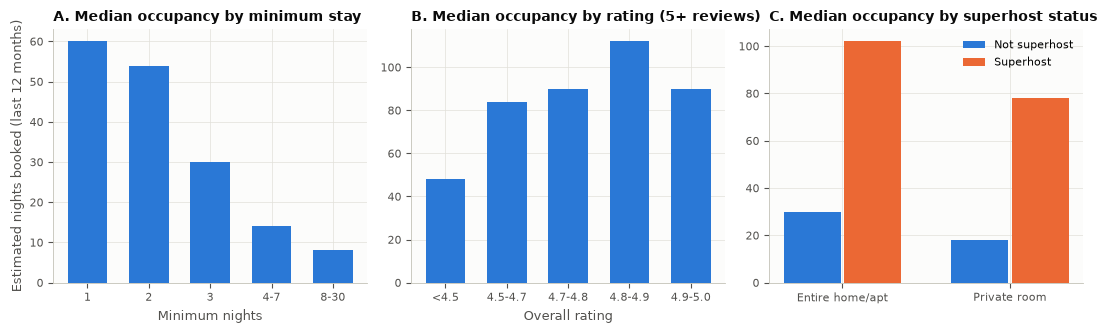

In [12]:
# Drivers of popularity: occupancy by minimum stay, by rating band and by superhost status
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))

mn_bins = pd.cut(df["minimum_nights"], [0, 1, 2, 3, 7, 30], labels=["1", "2", "3", "4-7", "8-30"])
s = df.groupby(mn_bins, observed=True)["estimated_occupancy_l365d"].median()
axes[0].bar(s.index.astype(str), s.values, color=C1, width=0.65)
axes[0].set_title("A. Median occupancy by minimum stay")
axes[0].set_xlabel("Minimum nights"); axes[0].set_ylabel("Estimated nights booked (last 12 months)")

rated = df[df["rated"]]
rb = pd.cut(rated["review_scores_rating"], [0, 4.5, 4.7, 4.8, 4.9, 5.0], labels=["<4.5", "4.5-4.7", "4.7-4.8", "4.8-4.9", "4.9-5.0"])
s = rated.groupby(rb, observed=True)["estimated_occupancy_l365d"].median()
axes[1].bar(s.index.astype(str), s.values, color=C1, width=0.65)
axes[1].set_title("B. Median occupancy by rating (5+ reviews)")
axes[1].set_xlabel("Overall rating")

s = df.groupby(["room_type", "superhost"])["estimated_occupancy_l365d"].median().unstack()
s = s.loc[["Entire home/apt", "Private room"]]
x = np.arange(len(s))
axes[2].bar(x - 0.18, s[0], width=0.34, color=C1, label="Not superhost")
axes[2].bar(x + 0.18, s[1], width=0.34, color=C2, label="Superhost")
axes[2].set_xticks(x, ["Entire home/apt", "Private room"])
axes[2].set_title("C. Median occupancy by superhost status")
axes[2].legend(loc="upper right")
fig.tight_layout()
savefig(fig, "q1_popularity_drivers")
RESULTS["q1_occ_by_minnights"] = df.groupby(mn_bins, observed=True)["estimated_occupancy_l365d"].median().to_dict()
RESULTS["q1_occ_by_rating"] = rated.groupby(rb, observed=True)["estimated_occupancy_l365d"].median().to_dict()
RESULTS["q1_occ_superhost"] = df.groupby("superhost")["estimated_occupancy_l365d"].median().to_dict()

In [13]:
# Room-type mix and property types among popular listings
mix = pd.crosstab(df["property_group"], df["popular"], normalize="columns").mul(100).round(1)
mix.columns = ["Other %", "Popular %"]
mix = mix.sort_values("Popular %", ascending=False)
RESULTS["q1_property_mix"] = mix.to_dict()
mix

,Other %,Popular %
property_group,,
Entire rental unit,46.6,54.2
Entire home,21.7,15.4
Other,11.5,15.0
Private room in home,11.8,5.5
Entire guesthouse,1.9,4.7
Entire condo,2.1,2.6
Private room in rental unit,4.4,2.6


In [14]:
q = RESULTS["q1"]; P, O = q["Popular (top 25%)"], q["Other listings"]
mn, rb_ = RESULTS["q1_occ_by_minnights"], RESULTS["q1_occ_by_rating"]
cal_ = RESULTS["q1_robust"]["Calendar: next 90 days unavailable"]
md(f"""**Q1 findings.** Popular listings (top 25%, at least {RESULTS['popular_threshold_nights']:.0f} estimated nights a year) do not charge more: their median price is ${P['Median price (AUD)']:,.0f} against ${O['Median price (AUD)']:,.0f} for the rest. What sets them apart is how they are run: {P['Superhost %']:.0f}% are superhosts ({O['Superhost %']:.0f}% of other listings), their median minimum stay is {P['Median minimum nights']:.0f} night against {O['Median minimum nights']:.0f}, and they offer more amenities ({P['Median amenities']:.0f} against {O['Median amenities']:.0f}). They are somewhat more often within a 500 m walk of a station ({P['Within 500 m walk of station %']:.0f}% against {O['Within 500 m walk of station %']:.0f}%), and commercial hosts are under-represented among them ({P['Commercial host (10+) %']:.0f}% against {O['Commercial host (10+) %']:.0f}%). Occupancy falls steeply with minimum stay ({mn['1']:.0f} nights a year at 1-night minimums against {mn['8-30']:.0f} at 8–30) and rises with rating up to the 4.8–4.9 band ({rb_['4.8-4.9']:.0f} nights against {rb_['<4.5']:.0f} below 4.5).

*How robust is this profile?* The occupancy estimate is built from review counts, so it agrees almost perfectly with reviews in the last 12 months (ρ = {RESULTS['rho_occ_reviews_ltm']}) and gives the same profile under that definition. It agrees only weakly with the 90-day forward calendar (ρ = {RESULTS['rho_occ_calendar']}): only {cal_['Overlap with main definition %']:.0f}% of the calendar's top quartile are also popular by occupancy. Under the calendar definition the superhost gap vanishes ({cal_['Superhost % (popular / other)']}) and minimum stays are equal ({cal_['Median min nights (popular / other)']}). Part of the superhost link is therefore mechanical: superhost status requires a record of completed, reviewed stays, which is exactly what the occupancy estimate counts. The pattern that survives every definition is that commercial hosts are under-represented among the busiest listings ({cal_['Commercial host % (popular / other)']} on the calendar measure). The calendar also mixes bookings with nights the host has blocked, so neither measure is a clean count of demand.""")

**Q1 findings.** Popular listings (top 25%, at least 120 estimated nights a year) do not charge more: their median price is $286 against $320 for the rest. What sets them apart is how they are run: 63% are superhosts (29% of other listings), their median minimum stay is 1 night against 2, and they offer more amenities (44 against 38). They are somewhat more often within a 500 m walk of a station (29% against 21%), and commercial hosts are under-represented among them (30% against 41%). Occupancy falls steeply with minimum stay (60 nights a year at 1-night minimums against 8 at 8–30) and rises with rating up to the 4.8–4.9 band (112 nights against 48 below 4.5).

*How robust is this profile?* The occupancy estimate is built from review counts, so it agrees almost perfectly with reviews in the last 12 months (ρ = 0.99) and gives the same profile under that definition. It agrees only weakly with the 90-day forward calendar (ρ = 0.11): only 22% of the calendar's top quartile are also popular by occupancy. Under the calendar definition the superhost gap vanishes (37 / 38) and minimum stays are equal (2 / 2). Part of the superhost link is therefore mechanical: superhost status requires a record of completed, reviewed stays, which is exactly what the occupancy estimate counts. The pattern that survives every definition is that commercial hosts are under-represented among the busiest listings (32 / 40 on the calendar measure). The calendar also mixes bookings with nights the host has blocked, so neither measure is a clean count of demand.

### Q2. How does price relate to guest ratings?
We use listings with 5 or more reviews so each rating reflects several guests. We report Spearman rank correlations (robust to skewed prices and the ceiling on ratings at 5), plot ratings across price deciles to look for non-linear patterns, and repeat the test within each room type so the room-type mix does not distort the result.

In [15]:
rated = df[df["rated"]].copy()
score_cols = ["review_scores_rating", "review_scores_accuracy", "review_scores_cleanliness", "review_scores_checkin",
              "review_scores_communication", "review_scores_location", "review_scores_value"]
nice = {c: c.replace("review_scores_", "").title() for c in score_cols}
corr = rated[["price"] + score_cols].rename(columns={"price": "Price", **nice}).corr(method="spearman")
RESULTS["q2_n_rated"] = len(rated)
RESULTS["q2_spearman_price"] = corr.loc["Price"].drop("Price").round(3).to_dict()

rho, p = stats.spearmanr(rated["price"], rated["review_scores_rating"])
RESULTS["q2_rho_overall"] = round(rho, 3); RESULTS["q2_p_overall"] = float(p)
by_room = {}
for rt, g in rated.groupby("room_type"):
    if len(g) >= 100:
        r_, p_ = stats.spearmanr(g["price"], g["review_scores_rating"])
        by_room[rt] = {"n": len(g), "rho": round(r_, 3), "p": float(p_)}
RESULTS["q2_by_room"] = by_room
print(f"Overall Spearman rho(price, rating) = {rho:.3f} (p = {p:.1e}); by room type: {by_room}")

rated["price_decile"] = pd.qcut(rated["price"], 10, labels=False) + 1
dec = rated.groupby("price_decile").agg(price_median=("price", "median"), rating_mean=("review_scores_rating", "mean"),
                                        value_mean=("review_scores_value", "mean"), location_mean=("review_scores_location", "mean"),
                                        share_below_45=("review_scores_rating", lambda s: 100 * (s < 4.5).mean()))
kw = stats.kruskal(*[g["review_scores_rating"] for _, g in rated.groupby("price_decile")])
RESULTS["q2_kruskal_p"] = float(kw.pvalue)
RESULTS["q2_deciles"] = dec.round(3).reset_index().to_dict(orient="list")

# Linear vs quadratic trend of rating on log price
lin = smf.ols("review_scores_rating ~ np.log(price)", rated).fit()
quad = smf.ols("review_scores_rating ~ np.log(price) + I(np.log(price)**2)", rated).fit()
RESULTS["q2_linear_r2"] = round(lin.rsquared, 4); RESULTS["q2_quad_r2"] = round(quad.rsquared, 4)
RESULTS["q2_linear_slope"] = round(lin.params["np.log(price)"], 4)
print(f"Linear R2 = {lin.rsquared:.4f}, quadratic R2 = {quad.rsquared:.4f}; Kruskal-Wallis across deciles p = {kw.pvalue:.1e}")
dec.round(3)

Overall Spearman rho(price, rating) = 0.216 (p = 1.0e-116); by room type: {'Entire home/apt': {'n': 9058, 'rho': np.float64(0.16), 'p': 7.001068327441023e-53}, 'Private room': {'n': 1914, 'rho': np.float64(0.207), 'p': 5.712265822460436e-20}}
Linear R2 = 0.0583, quadratic R2 = 0.0618; Kruskal-Wallis across deciles p = 1.1e-131


,price_median,rating_mean,value_mean,location_mean,share_below_45
price_decile,,,,,
1,103.00,4.583,4.573,4.642,30.929
2,160.00,4.717,4.666,4.795,15.818
3,205.41,4.741,4.674,4.821,12.941
4,246.00,4.758,4.677,4.837,11.202
5,285.50,4.756,4.671,4.846,10.354
6,325.24,4.763,4.670,4.859,10.063
7,375.00,4.770,4.671,4.865,9.891
8,435.75,4.782,4.680,4.876,8.514
9,553.47,4.799,4.694,4.891,8.265


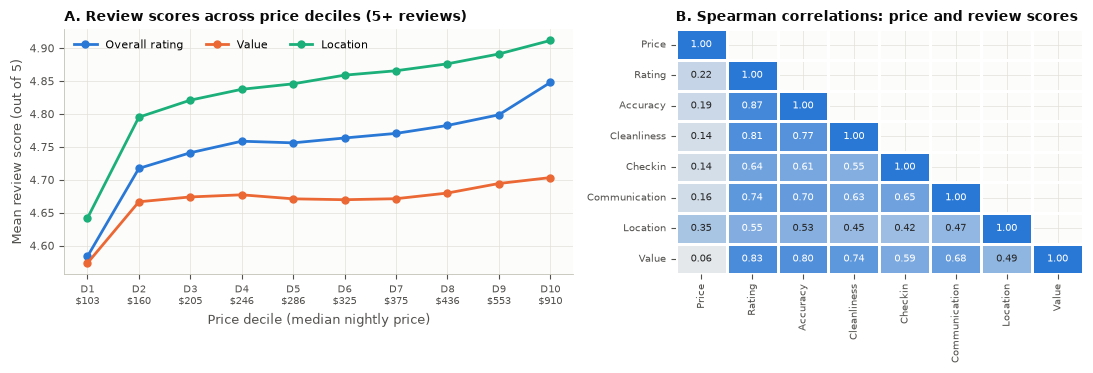

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1.25, 1]})
# A. Rating, value and location scores across price deciles
ax = axes[0]
ax.plot(dec.index, dec["rating_mean"], color=C1, marker="o", markersize=5, label="Overall rating")
ax.plot(dec.index, dec["value_mean"], color=C2, marker="o", markersize=5, label="Value")
ax.plot(dec.index, dec["location_mean"], color=C3, marker="o", markersize=5, label="Location")
ax.set_xticks(dec.index, [f"D{i}\n${v:,.0f}" for i, v in zip(dec.index, dec["price_median"])], fontsize=7)
ax.set_xlabel("Price decile (median nightly price)")
ax.set_ylabel("Mean review score (out of 5)")
ax.set_title("A. Review scores across price deciles (5+ reviews)")
ax.legend(loc="upper left", ncols=3)
# B. Spearman correlation heatmap
ax = axes[1]
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=LinearSegmentedColormap.from_list("div", ["#e34948", "#f0efec", "#2a78d6"]),
            vmin=-1, vmax=1, cbar=False, ax=ax, annot_kws={"size": 7}, linewidths=1, linecolor="white")
ax.set_title("B. Spearman correlations: price and review scores")
ax.tick_params(labelsize=7)
fig.tight_layout()
savefig(fig, "q2_price_vs_rating")

In [17]:
d_, sp = RESULTS["q2_deciles"], RESULTS["q2_spearman_price"]
md(f"""**Q2 findings.** Price and rating are positively but weakly related (Spearman ρ = {RESULTS['q2_rho_overall']:.2f}, n = {RESULTS['q2_n_rated']:,}), and the link holds within room types (entire homes ρ = {RESULTS['q2_by_room']['Entire home/apt']['rho']:.2f}, private rooms ρ = {RESULTS['q2_by_room']['Private room']['rho']:.2f}). It is non-linear: most of the gain comes from leaving the cheapest decile (mean rating {d_['rating_mean'][0]:.2f} at a median of ${d_['price_median'][0]:,.0f} against {d_['rating_mean'][1]:.2f} at ${d_['price_median'][1]:,.0f}), after which the curve is almost flat. The share of listings rated below 4.5 falls from {d_['share_below_45'][0]:.0f}% in the cheapest decile to {d_['share_below_45'][-1]:.0f}% in the dearest. Location is the sub-score most tied to price (ρ = {sp['Location']:.2f}) and Value the least (ρ = {sp['Value']:.2f}): guests at expensive listings are happier overall but do not feel they get better value. A linear fit on log price explains only {100 * RESULTS['q2_linear_r2']:.1f}% of rating variation ({100 * RESULTS['q2_quad_r2']:.1f}% with a quadratic term), so price is a weak signal of guest satisfaction.""")

**Q2 findings.** Price and rating are positively but weakly related (Spearman ρ = 0.22, n = 11,026), and the link holds within room types (entire homes ρ = 0.16, private rooms ρ = 0.21). It is non-linear: most of the gain comes from leaving the cheapest decile (mean rating 4.58 at a median of $103 against 4.72 at $160), after which the curve is almost flat. The share of listings rated below 4.5 falls from 31% in the cheapest decile to 4% in the dearest. Location is the sub-score most tied to price (ρ = 0.35) and Value the least (ρ = 0.06): guests at expensive listings are happier overall but do not feel they get better value. A linear fit on log price explains only 5.8% of rating variation (6.2% with a quadratic term), so price is a weak signal of guest satisfaction.

### Q3. How is location associated with listing characteristics and performance?
Three lenses: (i) **local government areas (LGAs)**, the neighbourhood units Inside Airbnb uses; (ii) **rail access**, measured as walking distance to the nearest station entrance on the current network, split by mode; (iii) **neighbourhood socio-economic status**, from the ABS SEIFA index for each listing's SA2.

In [18]:
lga = df.groupby("neighbourhood_cleansed").agg(
    listings=("id", "size"), median_price=("price", "median"), median_occupancy=("estimated_occupancy_l365d", "median"),
    mean_location_score=("review_scores_location", "mean"), entire_home_pct=("room_type", lambda s: 100 * (s == "Entire home/apt").mean()),
    median_walk_station_m=("walk_dist_station_m", "median"), median_dist_cbd_km=("dist_to_cbd_km", "median"),
    median_dist_beach_km=("dist_to_beach_km", "median"),
    commercial_pct=("host_tier", lambda s: 100 * (s == "Commercial (10+)").mean()))
lga_30 = lga[lga["listings"] >= 30].sort_values("median_price", ascending=False)
RESULTS["q3_lga_n"] = len(lga_30)
RESULTS["q3_lga_top_price"] = lga_30.head(5)[["listings", "median_price", "median_occupancy"]].round(1).to_dict(orient="index")
RESULTS["q3_lga_bottom_price"] = lga_30.tail(5)[["listings", "median_price", "median_occupancy"]].round(1).to_dict(orient="index")
RESULTS["q3_lga_top_occ"] = lga_30.sort_values("median_occupancy", ascending=False).head(5)[["listings", "median_price", "median_occupancy"]].round(1).to_dict(orient="index")
RESULTS["q3_sydney_lga_share"] = pct((df["neighbourhood_cleansed"] == "Sydney").mean())
RESULTS["q3_top5_lga_share"] = pct(df["neighbourhood_cleansed"].value_counts().head(5).sum() / len(df))

# Kruskal-Wallis: do price and occupancy differ by LGA?
big = df[df["neighbourhood_cleansed"].isin(lga_30.index)]
RESULTS["q3_kw_price_p"] = float(stats.kruskal(*[g["price"] for _, g in big.groupby("neighbourhood_cleansed")]).pvalue)
RESULTS["q3_kw_occ_p"] = float(stats.kruskal(*[g["estimated_occupancy_l365d"] for _, g in big.groupby("neighbourhood_cleansed")]).pvalue)
r_lga, p_lga = stats.spearmanr(lga_30["median_price"], lga_30["median_occupancy"])
RESULTS["q3_lga_price_occ_rho"] = round(r_lga, 2)
lga_30.round(1)

,listings,median_price,median_occupancy,mean_location_score,entire_home_pct,median_walk_station_m,median_dist_cbd_km,median_dist_beach_km,commercial_pct
neighbourhood_cleansed,,,,,,,,,
Pittwater,673,702.0,18.0,4.9,95.2,28971.0,28.6,0.6,24.4
Manly,665,418.4,48.0,4.9,93.5,9121.8,11.1,0.3,29.8
Woollahra,405,409.5,42.0,4.9,88.6,1169.0,3.3,1.1,35.8
Mosman,178,403.7,40.0,4.9,95.5,4347.5,6.2,0.6,36.5
Warringah,617,377.0,30.0,4.9,93.5,10640.6,14.1,1.0,14.3
Waverley,1289,364.0,48.0,4.9,89.0,2504.6,6.4,0.7,32.4
North Sydney,633,337.0,60.0,4.9,91.5,748.7,4.1,1.0,43.4
Sutherland Shire,415,335.0,66.0,4.9,88.2,13300.8,21.2,1.0,10.4
Camden,107,331.0,54.0,4.7,76.6,8057.9,45.1,15.1,24.3


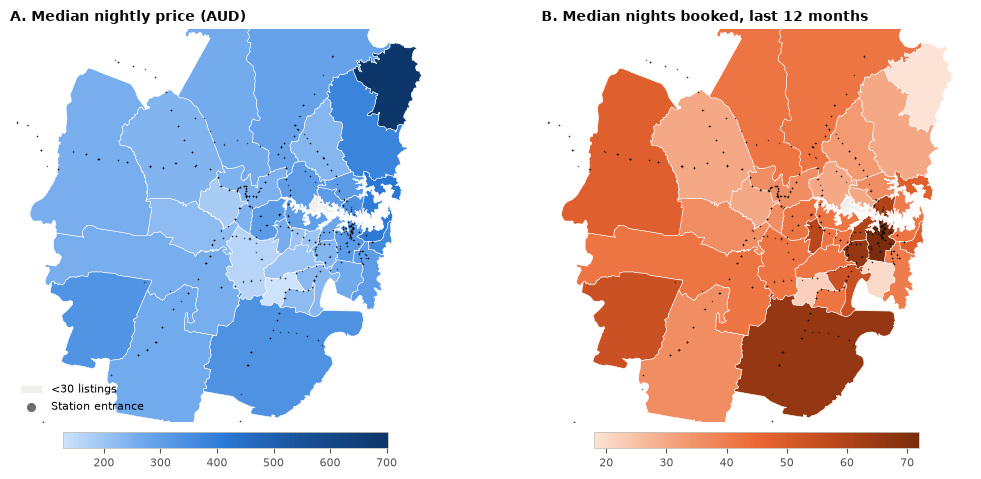

In [19]:
# Choropleth maps: median price and median occupancy by LGA, with station entrances overlaid
g = lga_shapes.merge(lga, left_on="neighbourhood", right_index=True, how="left")
g.loc[g["listings"] < 30, ["median_price", "median_occupancy"]] = np.nan
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
for ax, col, cmap, title in [(axes[0], "median_price", BLUES, "A. Median nightly price (AUD)"),
                             (axes[1], "median_occupancy", ORANGES, "B. Median nights booked, last 12 months")]:
    g.plot(column=col, cmap=cmap, linewidth=0.4, edgecolor="white", ax=ax, legend=True,
           missing_kwds={"color": "#f0efec", "label": "<30 listings"},
           legend_kwds={"shrink": 0.6, "orientation": "horizontal", "pad": 0.02})
    ax.scatter(st["lon"], st["lat"], s=1.2, color=INK, alpha=0.6, linewidths=0, label="Station entrance")
    ax.set_xlim(150.55, 151.38); ax.set_ylim(-34.18, -33.55)
    ax.set_axis_off(); ax.set_title(title)
axes[0].legend(loc="lower left", markerscale=6)
fig.tight_layout()
savefig(fig, "q3_lga_maps")

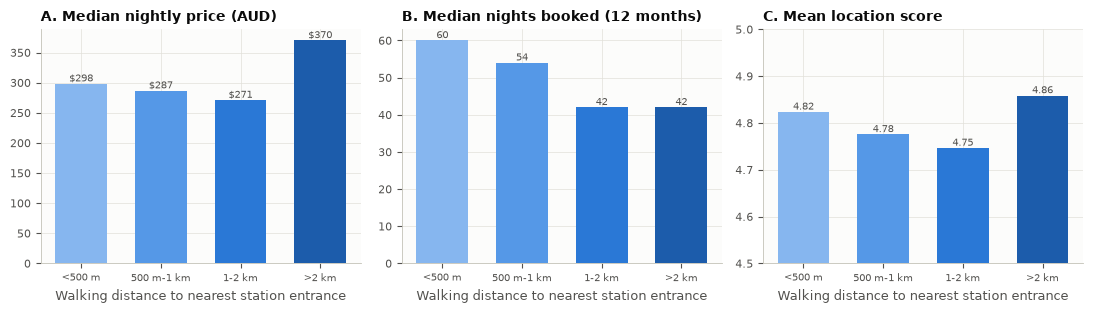

,listings,median_price,median_occupancy,mean_location_score,entire_home_pct,median_dist_cbd_km,median_dist_beach_km,unavailable_90d
transit_band,,,,,,,,
<500 m,3590,298.25,60.0,4.82,79.39,2.01,3.44,0.33
500 m-1 km,3455,286.67,54.0,4.78,78.47,4.43,3.91,0.30
1-2 km,2899,271.00,42.0,4.75,71.75,6.93,4.47,0.29
>2 km,5742,370.07,42.0,4.86,86.45,12.39,0.93,0.23


In [20]:
# Rail-access bands (walking distance): price, occupancy and location score
band = df.groupby("transit_band", observed=True).agg(
    listings=("id", "size"), median_price=("price", "median"), median_occupancy=("estimated_occupancy_l365d", "median"),
    mean_location_score=("review_scores_location", "mean"), entire_home_pct=("room_type", lambda s: 100 * (s == "Entire home/apt").mean()),
    median_dist_cbd_km=("dist_to_cbd_km", "median"), median_dist_beach_km=("dist_to_beach_km", "median"),
    unavailable_90d=("unavailable_rate_90d", "median"))
RESULTS["q3_bands"] = band.round(2).reset_index().astype({"transit_band": str}).to_dict(orient="list")
for col in ["price", "estimated_occupancy_l365d", "review_scores_location"]:
    r_, p_ = stats.spearmanr(df["walk_dist_station_m"], df[col], nan_policy="omit")
    RESULTS[f"q3_rho_dist_{col}"] = round(r_, 3)
r_, _ = stats.spearmanr(df["dist_to_cbd_km"], df["price"])
RESULTS["q3_rho_cbd_price"] = round(r_, 3)
r_, _ = stats.spearmanr(df["dist_to_cbd_km"], df["walk_dist_station_m"])
RESULTS["q3_rho_cbd_station"] = round(r_, 3)
r_, _ = stats.spearmanr(df["dist_to_beach_km"], df["walk_dist_station_m"])
RESULTS["q3_rho_beach_station"] = round(r_, 3)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, col, title, fmt in [(axes[0], "median_price", "A. Median nightly price (AUD)", "${:,.0f}"),
                            (axes[1], "median_occupancy", "B. Median nights booked (12 months)", "{:,.0f}"),
                            (axes[2], "mean_location_score", "C. Mean location score", "{:.2f}")]:
    bars = ax.bar(band.index.astype(str), band[col], color=BLUE_RAMP[:4], width=0.65)
    ax.set_title(title)
    ax.set_xlabel("Walking distance to nearest station entrance")
    for b, v in zip(bars, band[col]):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), fmt.format(v), ha="center", va="bottom", fontsize=7, color=INK2)
    ax.tick_params(axis="x", labelsize=7)
axes[2].set_ylim(4.5, 5.0)
fig.tight_layout()
savefig(fig, "q3_transit_bands")
band.round(2)

In [21]:
# Mode of the nearest station, and neighbourhood socio-economic status (SEIFA IRSAD decile of the listing's SA2)
near = df[df["near_station"] == 1]
by_mode = near.groupby("nearest_mode").agg(listings=("id", "size"), median_price=("price", "median"),
                                           median_occupancy=("estimated_occupancy_l365d", "median"),
                                           median_rail_mins_cbd=("rail_mins_to_cbd", "median"),
                                           median_services_hr=("services_per_hour", "median"),
                                           median_dist_cbd_km=("dist_to_cbd_km", "median"))
RESULTS["q3_by_mode_near"] = by_mode.round(1).to_dict(orient="index")
seifa_tab = df.groupby("irsad_decile").agg(listings=("id", "size"), median_price=("price", "median"),
                                           median_occupancy=("estimated_occupancy_l365d", "median"),
                                           near_station_pct=("near_station", lambda s: 100 * s.mean()))
r_, p_ = stats.spearmanr(df["irsad_score"], df["price"], nan_policy="omit")
RESULTS["q3_rho_irsad_price"] = round(r_, 3)
r_, _ = stats.spearmanr(df["irsad_score"], df["estimated_occupancy_l365d"], nan_policy="omit")
RESULTS["q3_rho_irsad_occ"] = round(r_, 3)
RESULTS["q3_seifa"] = seifa_tab.round(1).reset_index().to_dict(orient="list")
RESULTS["sa2_n"] = int(df["sa2_code"].nunique())
display(by_mode.round(1))
seifa_tab.round(1)

,listings,median_price,median_occupancy,median_rail_mins_cbd,median_services_hr,median_dist_cbd_km
nearest_mode,,,,,,
Light rail,1136,309.0,72.0,0.0,15.2,1.1
Metro,309,355.7,60.0,3.6,25.2,4.1
Train,2145,281.3,54.0,7.8,18.0,3.4


,listings,median_price,median_occupancy,near_station_pct
irsad_decile,,,,
1.0,310,200.4,36.0,6.5
2.0,251,217.4,48.0,10.8
3.0,207,198.6,42.0,25.6
4.0,143,230.0,36.0,7.0
5.0,117,166.0,36.0,6.0
6.0,335,177.0,36.0,18.2
7.0,716,213.2,30.0,21.8
8.0,965,256.5,48.0,16.3
9.0,3380,311.7,42.0,29.1


In [22]:
b, tp, bp = RESULTS["q3_bands"], RESULTS["q3_lga_top_price"], RESULTS["q3_lga_bottom_price"]
to, bm = RESULTS["q3_lga_top_occ"], RESULTS["q3_by_mode_near"]
md(f"""**Q3 findings.** Location strongly separates both price and demand (Kruskal-Wallis p < 0.001 for both across {RESULTS['q3_lga_n']} LGAs). The dearest LGAs are coastal and northern (Pittwater median ${tp['Pittwater']['median_price']:,.0f}, Manly ${tp['Manly']['median_price']:,.0f}, Woollahra ${tp['Woollahra']['median_price']:,.0f}); the cheapest are south-western and southern (Hurstville ${bp['Hurstville']['median_price']:,.0f}, Bankstown ${bp['Bankstown']['median_price']:,.0f}). Demand follows a different map: the City of Sydney has the highest median occupancy ({to['Sydney']['median_occupancy']:.0f} nights) at a mid-range price, while Pittwater, the dearest LGA, has one of the lowest ({tp['Pittwater']['median_occupancy']:.0f}). Across LGAs, price and occupancy are almost unrelated (ρ = {RESULTS['q3_lga_price_occ_rho']}).

**Rail access** (walking distance on the current network) is linked to demand more than to price. Listings within a 500 m walk of a station have the highest median occupancy ({b['median_occupancy'][0]:.0f} nights against {b['median_occupancy'][3]:.0f} beyond 2 km) and the highest forward booking rate, but lower median prices (${b['median_price'][0]:,.0f} against ${b['median_price'][3]:,.0f}). The rail-remote band is dear because it holds the beaches: its median listing is {b['median_dist_beach_km'][3]:.1f} km from a beach, against {b['median_dist_beach_km'][0]:.1f} km for the <500 m band. Among listings near a station, those near light rail are the most central and the busiest ({bm['Light rail']['median_occupancy']:.0f} nights) and those near the Metro the dearest (${bm['Metro']['median_price']:,.0f}). Neighbourhood status matters as well: listings in more advantaged SA2s charge more (ρ = {RESULTS['q3_rho_irsad_price']:.2f} with the SEIFA IRSAD score) but are barely booked more (ρ = {RESULTS['q3_rho_irsad_occ']:.2f}). These are raw associations; Analysis 1 separates rail access from what the listings are and where they sit.""")

**Q3 findings.** Location strongly separates both price and demand (Kruskal-Wallis p < 0.001 for both across 37 LGAs). The dearest LGAs are coastal and northern (Pittwater median $702, Manly $418, Woollahra $410); the cheapest are south-western and southern (Hurstville $127, Bankstown $160). Demand follows a different map: the City of Sydney has the highest median occupancy (72 nights) at a mid-range price, while Pittwater, the dearest LGA, has one of the lowest (18). Across LGAs, price and occupancy are almost unrelated (ρ = 0.13).

**Rail access** (walking distance on the current network) is linked to demand more than to price. Listings within a 500 m walk of a station have the highest median occupancy (60 nights against 42 beyond 2 km) and the highest forward booking rate, but lower median prices ($298 against $370). The rail-remote band is dear because it holds the beaches: its median listing is 0.9 km from a beach, against 3.4 km for the <500 m band. Among listings near a station, those near light rail are the most central and the busiest (72 nights) and those near the Metro the dearest ($356). Neighbourhood status matters as well: listings in more advantaged SA2s charge more (ρ = 0.25 with the SEIFA IRSAD score) but are barely booked more (ρ = 0.06). These are raw associations; Analysis 1 separates rail access from what the listings are and where they sit.

## Part A3 – Unguided analysis
### Analysis 1: Does rail access pay?
Q3 shows raw differences by walking-distance band, but listings near stations also tend to be smaller, more central apartments, and the dearest rail-remote listings are beach houses. We estimate the rail premium with log-price OLS regressions, adding controls one block at a time:
1. **Raw** – distance band only
2. **+ Structure** – room type, guests, bedrooms, bathrooms, shared bath, amenities
3. **+ LGA** – distance to the CBD and LGA fixed effects (our first-draft specification)
4. **+ Beach & attractions** – distance to the nearest beach and attractions within 1 km
5. **+ SA2** – SA2 fixed effects instead of LGA (compares listings within the same small neighbourhood)

The coefficient on each band (reference: more than 2 km walk) is converted to a percentage premium, `exp(b) - 1`. **Standard errors are clustered by host**: commercial hosts run hundreds of near-identical listings, so treating each listing as an independent observation (as our first draft did with HC3 errors) overstates precision.

We then ask the investor's real question: does rail access pay in **revenue**, which combines price and nights booked?

In [23]:
ref = 'C(transit_band, Treatment(reference=">2 km"))'
STRUCT = "C(room_type) + accommodates + bedrooms + bathrooms + bath_shared + amenities_count"
POI = "dist_to_cbd_km + np.log1p(dist_to_beach_km) + np.log1p(attractions_1km)"
specs = {
    "Raw": f"np.log(price) ~ {ref}",
    "+ Structure": f"np.log(price) ~ {ref} + {STRUCT}",
    "+ LGA": f"np.log(price) ~ {ref} + {STRUCT} + dist_to_cbd_km + C(neighbourhood_cleansed)",
    "+ Beach & attractions": f"np.log(price) ~ {ref} + {STRUCT} + {POI} + C(neighbourhood_cleansed)",
    "+ SA2": f"np.log(price) ~ {ref} + {STRUCT} + {POI} + C(sa2_code)",
}
FINAL = "+ SA2"
prem_rows, fits = [], {}
for name, f in specs.items():
    m = fit(f, df)
    fits[name] = m
    for b in BAND_LABELS[:3]:
        term = f'{ref}[T.{b}]'
        lo, hi = m.conf_int().loc[term]
        prem_rows.append({"Model": name, "Band": b, "Premium %": 100 * (np.exp(m.params[term]) - 1),
                          "CI low %": 100 * (np.exp(lo) - 1), "CI high %": 100 * (np.exp(hi) - 1),
                          "p": m.pvalues[term], "R2": m.rsquared})
prem = pd.DataFrame(prem_rows)
RESULTS["a3_premium"] = prem.round(4).to_dict(orient="list")
RESULTS["a3_r2"] = {k: round(v.rsquared, 3) for k, v in fits.items()}

def band_row(model_name, band="<500 m"):
    return prem[(prem["Model"] == model_name) & (prem["Band"] == band)].iloc[0]
adj = band_row(FINAL)
RESULTS["a3_adj_premium_500"] = round(adj["Premium %"], 2)
RESULTS["a3_adj_premium_500_ci"] = [round(adj["CI low %"], 2), round(adj["CI high %"], 2)]
RESULTS["a3_adj_premium_500_p"] = float(adj["p"])
RESULTS["median_price"] = float(df["price"].median())
RESULTS["a3_adj_premium_500_dollars"] = round(RESULTS["median_price"] * adj["Premium %"] / 100, 2)
RESULTS["a3_raw_premium_500"] = round(band_row("Raw")["Premium %"], 2)
RESULTS["a3_lga_premium_500"] = round(band_row("+ LGA")["Premium %"], 2)

# How much did clustering matter? Same final model with HC3 (listing-independent) errors
hc3 = smf.ols(specs[FINAL], df).fit(cov_type="HC3")
t500 = f'{ref}[T.<500 m]'
RESULTS["a3_se_cluster_vs_hc3"] = [round(fits[FINAL].bse[t500], 4), round(hc3.bse[t500], 4)]
# Is <500 m different from 500 m-1 km? (both measured against >2 km, so test the difference directly)
contrast = np.zeros(len(fits[FINAL].params))
contrast[fits[FINAL].params.index.get_loc(t500)] = 1
contrast[fits[FINAL].params.index.get_loc(f"{ref}[T.500 m-1 km]")] = -1
ct = fits[FINAL].t_test(contrast)
RESULTS["a3_contrast_500_vs_1k"] = {"diff_pct": round(100 * (np.exp(float(ct.effect[0])) - 1), 2), "p": float(ct.pvalue)}
print(f"Final model: <500 m premium {adj['Premium %']:.1f}% (95% CI {adj['CI low %']:.1f} to {adj['CI high %']:.1f}), "
      f"SE clustered {fits[FINAL].bse[t500]:.4f} vs HC3 {hc3.bse[t500]:.4f}; <500 m vs 500 m-1 km: "
      f"{RESULTS['a3_contrast_500_vs_1k']['diff_pct']}% (p = {float(ct.pvalue):.3f})")
prem.round(3)

Final model: <500 m premium 1.7% (95% CI -3.0 to 6.6), SE clustered 0.0241 vs HC3 0.0178; <500 m vs 500 m-1 km: -0.66% (p = 0.591)


,Model,Band,Premium %,CI low %,CI high %,p,R2
0,Raw,<500 m,-25.834,-30.348,-21.028,0.000,0.060
1,Raw,500 m-1 km,-28.537,-32.774,-24.032,0.000,0.060
2,Raw,1-2 km,-33.117,-37.600,-28.312,0.000,0.060
3,+ Structure,<500 m,-7.390,-10.283,-4.404,0.000,0.631
4,+ Structure,500 m-1 km,-11.675,-14.300,-8.968,0.000,0.631
5,+ Structure,1-2 km,-15.679,-18.439,-12.826,0.000,0.631
6,+ LGA,<500 m,-0.113,-3.752,3.664,0.952,0.700
7,+ LGA,500 m-1 km,-1.824,-4.974,1.430,0.268,0.700
8,+ LGA,1-2 km,-5.064,-7.939,-2.100,0.001,0.700
9,+ Beach & attractions,<500 m,1.111,-2.594,4.956,0.562,0.707


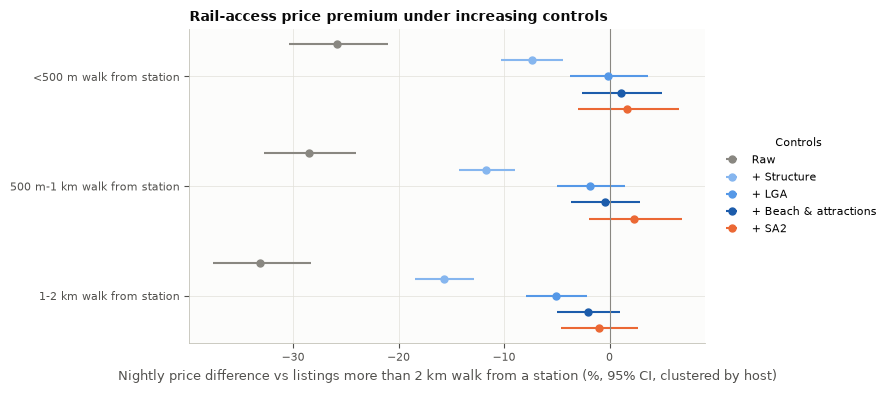

In [24]:
fig, ax = plt.subplots(figsize=(9, 4.0))
ramp = [MUTED, BLUE_RAMP[0], BLUE_RAMP[1], BLUE_RAMP[3], C2]   # final model (SA2) highlighted
order = list(specs)
offsets = np.linspace(-0.3, 0.3, len(order))
for (name, off, col) in zip(order, offsets, ramp):
    gdf_ = prem[prem["Model"] == name]
    y = np.arange(3) + off
    ax.errorbar(gdf_["Premium %"], y, xerr=[gdf_["Premium %"] - gdf_["CI low %"], gdf_["CI high %"] - gdf_["Premium %"]],
                fmt="o", color=col, markersize=5, capsize=0, elinewidth=1.5, label=name)
ax.axvline(0, color=MUTED, linewidth=0.8)
ax.set_yticks(np.arange(3), [f"{b} walk from station" for b in BAND_LABELS[:3]])
ax.invert_yaxis()
ax.set_xlabel("Nightly price difference vs listings more than 2 km walk from a station (%, 95% CI, clustered by host)")
ax.set_title("Rail-access price premium under increasing controls")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), title="Controls", title_fontsize=8)
fig.tight_layout()
savefig(fig, "a3_transit_premium")

**Shape, quality and where it matters.** Bands force a step shape on the relationship. We replace them with a smooth curve (a natural cubic spline in log walking distance) in the final model, then ask whether the *kind* of rail access matters (mode, frequency, travel time to the CBD, patronage) and whether proximity matters more in some rings of the city than others.

In [25]:
# Natural cubic spline in log walking distance, final controls; effect shown relative to a 2 km walk
x_log = np.log(df["walk_dist_station_m"].clip(lower=25))
spl = dmatrix("cr(x, df=4, constraints='center') - 1", pd.DataFrame({"x": x_log}), return_type="dataframe")
spl.columns = [f"spl{i}" for i in range(spl.shape[1])]
dfs = pd.concat([df, spl], axis=1)
SPL = " + ".join(spl.columns)
m_spl = fit(f"np.log(price) ~ {SPL} + {STRUCT} + {POI} + C(sa2_code)", dfs)
grid = np.exp(np.linspace(np.log(50), np.log(5000), 80))
Bg = np.asarray(build_design_matrices([spl.design_info], {"x": np.log(grid)})[0])
Br = np.asarray(build_design_matrices([spl.design_info], {"x": np.log([2000.0])})[0])
D = Bg - Br
beta = m_spl.params[spl.columns].values
V = m_spl.cov_params().loc[spl.columns, spl.columns].values
eff = D @ beta; se = np.sqrt(np.einsum("ij,jk,ik->i", D, V, D))
curve = pd.DataFrame({"walk_m": grid, "effect_pct": 100 * (np.exp(eff) - 1),
                      "lo": 100 * (np.exp(eff - 1.96 * se) - 1), "hi": 100 * (np.exp(eff + 1.96 * se) - 1)})
RESULTS["a3_curve"] = curve.iloc[::8].round(2).to_dict(orient="list")
RESULTS["a3_curve_at"] = {f"{m} m": round(float(np.interp(np.log(m), np.log(grid), curve["effect_pct"])), 2) for m in [100, 250, 500, 1000]}

# Heterogeneity: the <500 m effect separately for inner, middle and outer rings, and by mode of the nearest station
CTRL = f"{STRUCT} + {POI} + C(sa2_code)"
m_ring = fit(f"np.log(price) ~ near_station:C(cbd_ring) + {CTRL}", df)
m_mode = fit(f"np.log(price) ~ near_station:C(nearest_mode) + {CTRL}", df)
def effect_table(m, prefix):
    rows = []
    for term in [t for t in m.params.index if t.startswith(prefix)]:
        lo, hi = m.conf_int().loc[term]
        lvl = re.search(r"\[(.*)\]", term).group(1).replace("T.", "")
        rows.append({"Group": lvl, "Premium %": 100 * (np.exp(m.params[term]) - 1), "CI low %": 100 * (np.exp(lo) - 1),
                     "CI high %": 100 * (np.exp(hi) - 1), "p": m.pvalues[term]})
    return pd.DataFrame(rows)
ring_tab = effect_table(m_ring, "near_station:C(cbd_ring)")
mode_tab = effect_table(m_mode, "near_station:C(nearest_mode)")
ring_tab["n near"] = ring_tab["Group"].map(df[df["near_station"] == 1]["cbd_ring"].astype(str).value_counts())
mode_tab["n near"] = mode_tab["Group"].map(df[df["near_station"] == 1]["nearest_mode"].value_counts())
RESULTS["a3_ring"] = ring_tab.round(4).to_dict(orient="list")
RESULTS["a3_mode"] = mode_tab.round(4).to_dict(orient="list")

# Quality of rail access: replace distance bands with continuous service measures (all for the nearest station by walking)
m_q = fit(f"np.log(price) ~ np.log(walk_dist_station_m) + np.log1p(services_per_hour) + rail_mins_to_cbd + log_patronage + {CTRL}",
          df.dropna(subset=["log_patronage"]))
q_terms = {"np.log(walk_dist_station_m)": "log walking distance (x2 distance)", "np.log1p(services_per_hour)": "log off-peak services/hour (x2)",
           "rail_mins_to_cbd": "rail minutes to CBD (+10 min)", "log_patronage": "log station patronage (x2)"}
scale = {"np.log(walk_dist_station_m)": np.log(2), "np.log1p(services_per_hour)": np.log(2), "rail_mins_to_cbd": 10, "log_patronage": np.log(2)}
qual = pd.DataFrame([{"Measure": lab, "Price effect %": 100 * (np.exp(m_q.params[t] * scale[t]) - 1),
                      "CI low %": 100 * (np.exp(m_q.conf_int().loc[t, 0] * scale[t]) - 1),
                      "CI high %": 100 * (np.exp(m_q.conf_int().loc[t, 1] * scale[t]) - 1), "p": m_q.pvalues[t]}
                     for t, lab in q_terms.items()])
RESULTS["a3_quality"] = qual.round(4).to_dict(orient="list")
display(ring_tab.round(3)); display(mode_tab.round(3))
qual.round(3)

,Group,Premium %,CI low %,CI high %,p,n near
0,Inner (<5 km),-3.263,-6.291,-0.137,0.041,2475
1,Middle (5-15 km),4.570,0.213,9.117,0.040,755
2,Outer (>15 km),6.814,0.520,13.502,0.033,360


,Group,Premium %,CI low %,CI high %,p,n near
0,Light rail,3.080,-1.016,7.347,0.143,1136
1,Metro,-3.239,-10.586,4.712,0.414,309
2,Train,-0.164,-2.768,2.510,0.903,2145


,Measure,Price effect %,CI low %,CI high %,p
0,log walking distance (x2 distance),-0.806,-1.864,0.262,0.139
1,log off-peak services/hour (x2),-0.545,-3.113,2.092,0.682
2,rail minutes to CBD (+10 min),0.524,-2.229,3.355,0.712
3,log station patronage (x2),-0.460,-1.763,0.859,0.492


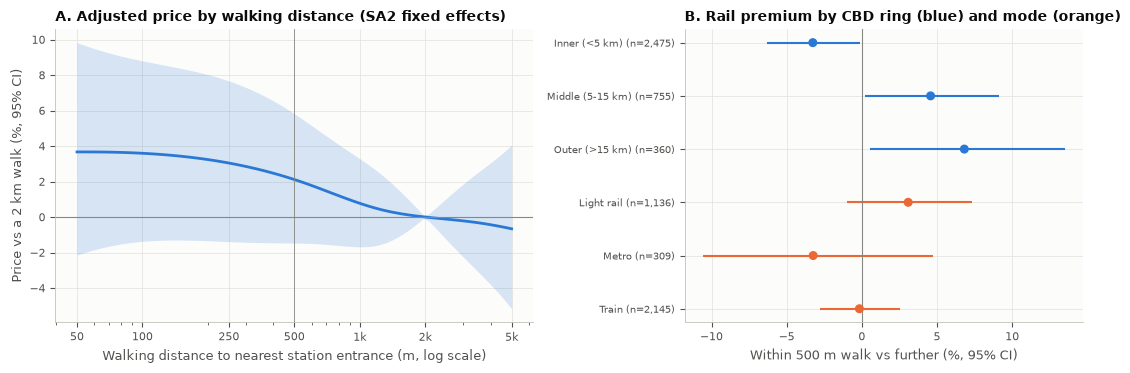

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1.2, 1]})
ax = axes[0]
ax.fill_between(curve["walk_m"], curve["lo"], curve["hi"], color=C1, alpha=0.18, linewidth=0)
ax.plot(curve["walk_m"], curve["effect_pct"], color=C1)
ax.axhline(0, color=MUTED, linewidth=0.8); ax.axvline(500, color=MUTED, linewidth=0.6)
ax.set_xscale("log"); ax.set_xticks([50, 100, 250, 500, 1000, 2000, 5000], ["50", "100", "250", "500", "1k", "2k", "5k"])
ax.set_xlabel("Walking distance to nearest station entrance (m, log scale)")
ax.set_ylabel("Price vs a 2 km walk (%, 95% CI)")
ax.set_title("A. Adjusted price by walking distance (SA2 fixed effects)")
ax = axes[1]
both = pd.concat([ring_tab.assign(kind="CBD ring"), mode_tab.assign(kind="Mode")]).reset_index(drop=True)
y = np.arange(len(both))
cols = [C1 if k == "CBD ring" else C2 for k in both["kind"]]
ax.errorbar(both["Premium %"], y, xerr=[both["Premium %"] - both["CI low %"], both["CI high %"] - both["Premium %"]],
            fmt="none", ecolor=cols, elinewidth=1.5)
ax.scatter(both["Premium %"], y, color=cols, s=30, zorder=3)
ax.set_yticks(y, [f"{g} (n={int(n):,})" for g, n in zip(both["Group"], both["n near"])])
ax.invert_yaxis(); ax.axvline(0, color=MUTED, linewidth=0.8)
ax.set_xlabel("Within 500 m walk vs further (%, 95% CI)")
ax.set_title("B. Rail premium by CBD ring (blue) and mode (orange)")
ax.tick_params(axis="y", labelsize=7)
fig.tight_layout()
savefig(fig, "a3_rail_shape")

**Demand and revenue.** Price is only half of what an investor earns. We estimate the <500 m effect on demand and revenue with the same final controls, and check that the result does not depend on one particular demand measure:
- *Estimated occupancy* (nights a year, review-based): OLS, with and without price as a control. Price is set together with demand, so controlling for it can bias the rail effect; we show both. A Poisson model treats occupancy as a count (17% of listings have zero nights) and gives a % effect.
- *Calendar unavailability* (share of the next 90 days blocked or booked) and *reviews in the last 12 months* – independent demand signals.
- *Estimated revenue* (price × occupancy): Poisson pseudo-maximum likelihood (PPML; Santos Silva & Tenreyro, 2006), which handles zero-revenue listings without dropping them or taking logs of zero.

In [27]:
D_CTRL = f"{ref} + {CTRL}"
demand_specs = [
    ("Occupancy, nights (OLS)", "estimated_occupancy_l365d", None, "nights"),
    ("Occupancy, nights (OLS, + log price)", "estimated_occupancy_l365d", None, "nights", "price"),
    ("Occupancy (Poisson)", "estimated_occupancy_l365d", sm.families.Poisson(), "%"),
    ("Calendar unavailable, next 90 days (OLS)", "unavailable_rate_90d", None, "pp"),
    ("Reviews, last 12 months (Poisson)", "number_of_reviews_ltm", sm.families.Poisson(), "%"),
    ("Revenue (PPML)", "estimated_revenue_l365d", sm.families.Poisson(), "%"),
    ("Revenue (PPML, + log price)", "estimated_revenue_l365d", sm.families.Poisson(), "%", "price"),
]
dem_rows = {}
for spec in demand_specs:
    label, y, fam, unit = spec[:4]
    f = f"{y} ~ {D_CTRL}" + (" + np.log(price)" if len(spec) > 4 else "")
    m = fit(f, df, family=fam)
    b, (lo, hi), p_ = m.params[t500], m.conf_int().loc[t500], m.pvalues[t500]
    if unit == "%":
        b, lo, hi = (100 * (np.exp(v) - 1) for v in (b, lo, hi))
    elif unit == "pp":
        b, lo, hi = (100 * v for v in (b, lo, hi))
    dem_rows[label] = {"Effect of <500 m walk": b, "CI low": lo, "CI high": hi, "Unit": unit, "p": p_, "n": int(m.nobs)}
dem = pd.DataFrame(dem_rows).T
RESULTS["a3_demand"] = {k: {kk: (float(vv) if kk != "Unit" else vv) for kk, vv in v.items()} for k, v in dem_rows.items()}
occ = dem_rows["Occupancy, nights (OLS, + log price)"]
RESULTS["a3_occ_500_nights"] = round(occ["Effect of <500 m walk"], 2)
RESULTS["a3_occ_500_p"] = float(occ["p"])
RESULTS["a3_occ_500_ci"] = [round(occ["CI low"], 2), round(occ["CI high"], 2)]
rev = dem_rows["Revenue (PPML)"]
RESULTS["a3_rev_500_pct"] = round(rev["Effect of <500 m walk"], 2)
RESULTS["a3_rev_500_ci"] = [round(rev["CI low"], 2), round(rev["CI high"], 2)]
RESULTS["a3_rev_500_p"] = float(rev["p"])
RESULTS["median_revenue"] = float(df["estimated_revenue_l365d"].median())
dem

,Effect of <500 m walk,CI low,CI high,Unit,p,n
"Occupancy, nights (OLS)",-1.887487,-10.032668,6.257694,nights,0.649697,15686
"Occupancy, nights (OLS, + log price)",-1.060357,-8.799885,6.679171,nights,0.788295,15686
Occupancy (Poisson),-1.372735,-12.211403,10.80411,%,0.815985,15686
"Calendar unavailable, next 90 days (OLS)",-1.241568,-4.933081,2.449944,pp,0.50977,15686
"Reviews, last 12 months (Poisson)",0.160023,-12.721734,14.94305,%,0.981838,15686
Revenue (PPML),2.155472,-9.206723,14.939574,%,0.722975,15686
"Revenue (PPML, + log price)",2.399698,-9.05517,15.297352,%,0.695217,15686


**Robustness across data versions.** We re-estimate the final price model (i) on the March 2026 snapshot, which falls at the end of summer when beach demand peaks, and (ii) on the June sample using our first draft's rail measure (straight-line distance to the 2020 entrances), to see how much the outdated network changed the answer.

In [28]:
df_mar = add_location_features(df_mar, st, st_info, tag="_mar")
rob = {}
for label, data, band_col in [("June 2026, walking distance, current network (main)", df, None),
                              ("March 2026, walking distance, current network", df_mar, None),
                              ("June 2026, straight line, 2020 network (first draft)", df, "dist_station_2020_m"),
                              ("June 2026, straight line, current network", df, "dist_to_nearest_station_m")]:
    d = data.copy()
    if band_col:
        d["transit_band"] = pd.cut(d[band_col], [0, 500, 1000, 2000, np.inf], labels=BAND_LABELS)
    m = fit(specs[FINAL], d)
    lo, hi = m.conf_int().loc[t500]
    rob[label] = {"Premium %": 100 * (np.exp(m.params[t500]) - 1), "CI low %": 100 * (np.exp(lo) - 1),
                  "CI high %": 100 * (np.exp(hi) - 1), "p": m.pvalues[t500], "n": int(m.nobs)}
rob = pd.DataFrame(rob).T
RESULTS["a3_robust"] = rob.round(4).to_dict(orient="index")
rob.round(3)

,Premium %,CI low %,CI high %,p,n
"June 2026, walking distance, current network (main)",1.667,-3.029,6.590,0.493,15686.0
"March 2026, walking distance, current network",0.982,-3.499,5.672,0.673,13194.0
"June 2026, straight line, 2020 network (first draft)",5.764,0.917,10.843,0.019,15686.0
"June 2026, straight line, current network",3.244,-1.487,8.202,0.182,15686.0


In [29]:
rob_, dm = RESULTS["a3_robust"], RESULTS["a3_demand"]
rg = pd.DataFrame(RESULTS["a3_ring"]).set_index("Group")
first, mar = rob_["June 2026, straight line, 2020 network (first draft)"], rob_["March 2026, walking distance, current network"]
occ0, occ_, rev_, cal90 = (dm[k] for k in ["Occupancy, nights (OLS)", "Occupancy, nights (OLS, + log price)", "Revenue (PPML)", "Calendar unavailable, next 90 days (OLS)"])
se_c, se_h = RESULTS["a3_se_cluster_vs_hc3"]
p_quality = min(min(RESULTS["a3_quality"]["p"]), min(RESULTS["a3_mode"]["p"]))
md(f"""**Analysis 1 findings – on average rail access does not pay; in the suburbs it does.**
- *Price.* The raw data shows a discount: listings within a 500 m walk of a station are {abs(RESULTS['a3_raw_premium_500']):.0f}% cheaper than those more than 2 km away. Listing structure removes most of it and location controls remove the rest. With SA2 fixed effects, beaches and attractions, the difference is {RESULTS['a3_adj_premium_500']:+.1f}% ({ci_txt(*RESULTS['a3_adj_premium_500_ci'])}, {p_txt(RESULTS['a3_adj_premium_500_p'])}), about ${RESULTS['a3_adj_premium_500_dollars']:,.0f} a night at the median price. The smooth curve (Figure A) tells the same story: a listing 100 m from a station is priced only {RESULTS['a3_curve_at']['100 m']:.1f}% above one 2 km away, and the confidence band includes zero. Neither the mode of the station, its off-peak frequency, its rail time to the CBD nor its patronage moves price measurably (all p ≥ {p_quality:.2f}).
- *Where it does pay.* The average hides a split by ring (Figure B). In the inner city (< 5 km from Town Hall), where almost everything is walkable, listings next to a station are {abs(rg.loc['Inner (<5 km)', 'Premium %']):.1f}% *cheaper* ({p_txt(rg.loc['Inner (<5 km)', 'p'])}), possibly reflecting noise and busier streets. In the middle ring they earn {rg.loc['Middle (5-15 km)', 'Premium %']:+.1f}% ({p_txt(rg.loc['Middle (5-15 km)', 'p'])}) and in the outer suburbs {rg.loc['Outer (>15 km)', 'Premium %']:+.1f}% ({p_txt(rg.loc['Outer (>15 km)', 'p'])}), where a station is the guest's link to the city.
- *Demand and revenue.* Within the same SA2, being near a station adds no measurable demand: {occ0['Effect of <500 m walk']:+.1f} nights a year ({ci_txt(occ0['CI low'], occ0['CI high'], ' nights')}), {occ_['Effect of <500 m walk']:+.1f} nights when price is also held fixed, and {cal90['Effect of <500 m walk']:+.1f} percentage points on the 90-day calendar. Estimated revenue changes by {rev_['Effect of <500 m walk']:+.1f}% ({ci_txt(rev_['CI low'], rev_['CI high'])}), which is not significant. Our first draft reported +4.8 nights (p = 0.04); that result relied on LGA-level controls and listing-level standard errors and does not survive.
- *Robustness.* Clustering by host makes the standard error on the <500 m premium {se_c / se_h:.1f}x larger than the listing-independent (HC3) version. The March 2026 snapshot gives {mar['Premium %']:+.1f}% ({p_txt(mar['p'])}), so the null result is not a winter artefact. With the first draft's measure (straight-line distance to the 2020 entrances) the same model shows a significant {first['Premium %']:+.1f}% premium ({p_txt(first['p'])}): the outdated network and straight-line distances were enough to manufacture a 'rail premium'.

*Limitations.* These are associations within SA2s, not causal effects; a station's immediate surroundings can differ from the rest of its SA2 in ways we do not observe. Prices are asking prices, occupancy and revenue are Inside Airbnb estimates built from reviews, and the GTFS timetable (October 2026) is a few months later than the listings snapshot.""")

**Analysis 1 findings – on average rail access does not pay; in the suburbs it does.**
- *Price.* The raw data shows a discount: listings within a 500 m walk of a station are 26% cheaper than those more than 2 km away. Listing structure removes most of it and location controls remove the rest. With SA2 fixed effects, beaches and attractions, the difference is +1.7% (95% CI -3.0% to +6.6%, p = 0.49), about $5 a night at the median price. The smooth curve (Figure A) tells the same story: a listing 100 m from a station is priced only 3.6% above one 2 km away, and the confidence band includes zero. Neither the mode of the station, its off-peak frequency, its rail time to the CBD nor its patronage moves price measurably (all p ≥ 0.14).
- *Where it does pay.* The average hides a split by ring (Figure B). In the inner city (< 5 km from Town Hall), where almost everything is walkable, listings next to a station are 3.3% *cheaper* (p = 0.04), possibly reflecting noise and busier streets. In the middle ring they earn +4.6% (p = 0.04) and in the outer suburbs +6.8% (p = 0.03), where a station is the guest's link to the city.
- *Demand and revenue.* Within the same SA2, being near a station adds no measurable demand: -1.9 nights a year (95% CI -10.0 nights to +6.3 nights), -1.1 nights when price is also held fixed, and -1.2 percentage points on the 90-day calendar. Estimated revenue changes by +2.2% (95% CI -9.2% to +14.9%), which is not significant. Our first draft reported +4.8 nights (p = 0.04); that result relied on LGA-level controls and listing-level standard errors and does not survive.
- *Robustness.* Clustering by host makes the standard error on the <500 m premium 1.4x larger than the listing-independent (HC3) version. The March 2026 snapshot gives +1.0% (p = 0.67), so the null result is not a winter artefact. With the first draft's measure (straight-line distance to the 2020 entrances) the same model shows a significant +5.8% premium (p = 0.02): the outdated network and straight-line distances were enough to manufacture a 'rail premium'.

*Limitations.* These are associations within SA2s, not causal effects; a station's immediate surroundings can differ from the rest of its SA2 in ways we do not observe. Prices are asking prices, occupancy and revenue are Inside Airbnb estimates built from reviews, and the GTFS timetable (October 2026) is a few months later than the listings snapshot.

### Analysis 2: Do commercial multi-listing hosts differ from single-listing hosts?
We split hosts by how many Sydney listings they run (`calculated_host_listings_count`): **single (1)**, **small multi (2–9)** and **commercial (10+)**. We compare guest satisfaction (overall and sub-scores), pricing, demand, rail access and operating patterns, using Kruskal-Wallis tests across the three tiers and Mann-Whitney tests between commercial and single hosts. The adjusted rating gap is estimated with SA2 fixed effects and standard errors clustered by host. Clustering matters most here: 259 hosts run more than a third of all listings, so their listings' ratings are far from independent.

In [30]:
tier = df.groupby("host_tier", observed=True).agg(
    listings=("id", "size"), hosts=("host_id", "nunique"), median_price=("price", "median"),
    median_occupancy=("estimated_occupancy_l365d", "median"), median_availability=("availability_365", "median"),
    median_min_nights=("minimum_nights", "median"), superhost_pct=("superhost", lambda s: 100 * s.mean()),
    entire_home_pct=("room_type", lambda s: 100 * (s == "Entire home/apt").mean()),
    median_walk_station_m=("walk_dist_station_m", "median"), within_500m_pct=("near_station", lambda s: 100 * s.mean()),
    median_dist_cbd_km=("dist_to_cbd_km", "median"), sydney_lga_pct=("neighbourhood_cleansed", lambda s: 100 * (s == "Sydney").mean()))
tier["listing_share_pct"] = 100 * tier["listings"] / tier["listings"].sum()
rated_t = df[df["rated"]]
sub = rated_t.groupby("host_tier", observed=True)[score_cols].mean().rename(columns=nice)
tier = tier.join(sub[["Rating"]].rename(columns={"Rating": "mean_rating_5plus"}))
tier["below_4_5_pct"] = rated_t.groupby("host_tier", observed=True)["review_scores_rating"].apply(lambda s: 100 * (s < 4.5).mean())

single = rated_t[rated_t["host_tier"] == "Single (1)"]
comm = rated_t[rated_t["host_tier"] == "Commercial (10+)"]
tests2 = {
    "rating_kw_p": stats.kruskal(*[g["review_scores_rating"] for _, g in rated_t.groupby("host_tier", observed=True)]).pvalue,
    "rating_mw_p": stats.mannwhitneyu(single["review_scores_rating"], comm["review_scores_rating"]).pvalue,
    "dist_mw_p": stats.mannwhitneyu(df.loc[df["host_tier"] == "Single (1)", "walk_dist_station_m"],
                                    df.loc[df["host_tier"] == "Commercial (10+)", "walk_dist_station_m"]).pvalue,
}
# Effect size: rank-biserial correlation for the rating comparison
u = stats.mannwhitneyu(single["review_scores_rating"], comm["review_scores_rating"]).statistic
tests2["rating_rank_biserial"] = 2 * u / (len(single) * len(comm)) - 1
chi = stats.chi2_contingency(pd.crosstab(df["host_tier"], df["near_station"]))
tests2["near_station_chi2_p"] = chi.pvalue

# Does the rating gap survive controls for room type, price, location and review volume?
gap_f = 'review_scores_rating ~ C(host_tier, Treatment(reference="Single (1)")) + C(room_type) + np.log(price) + np.log(number_of_reviews) + dist_to_cbd_km + C(sa2_code)'
m_gap = fit(gap_f, rated_t)
m_gap_hc3 = smf.ols(gap_f, rated_t).fit(cov_type="HC3")
term = 'C(host_tier, Treatment(reference="Single (1)"))[T.Commercial (10+)]'
tests2["rating_gap_adj"] = m_gap.params[term]
tests2["rating_gap_adj_ci"] = list(m_gap.conf_int().loc[term])
tests2["rating_gap_adj_p"] = m_gap.pvalues[term]
tests2["rating_gap_adj_ci_hc3"] = list(m_gap_hc3.conf_int().loc[term])
# Cleanliness, the largest raw gap, with the same controls
m_clean = fit(gap_f.replace("review_scores_rating ~", "review_scores_cleanliness ~"), rated_t)
tests2["cleanliness_gap_adj"] = m_clean.params[term]
tests2["cleanliness_gap_adj_ci"] = list(m_clean.conf_int().loc[term])
# Demand gap: occupancy of commercial vs single hosts with the A3.1 controls plus price
m_occ_t = fit(f'estimated_occupancy_l365d ~ C(host_tier, Treatment(reference="Single (1)")) + np.log(price) + {CTRL}', df)
tests2["occupancy_gap_adj"] = m_occ_t.params[term]
tests2["occupancy_gap_adj_ci"] = list(m_occ_t.conf_int().loc[term])
tests2["occupancy_gap_adj_p"] = m_occ_t.pvalues[term]
RESULTS["a3_host_tier"] = tier.round(3).reset_index().astype({"host_tier": str}).to_dict(orient="list")
RESULTS["a3_host_subscores"] = sub.round(3).to_dict(orient="index")
RESULTS["a3_host_tests"] = {k: (float(v) if not isinstance(v, list) else [round(x, 4) for x in v]) for k, v in tests2.items()}
print({k: v for k, v in RESULTS["a3_host_tests"].items()})
tier.round(2).T

{'rating_kw_p': 0.0, 'rating_mw_p': 8.22447774638725e-308, 'dist_mw_p': 1.4255963747464176e-232, 'rating_rank_biserial': 0.49822767055410755, 'near_station_chi2_p': 5.3503346638481536e-89, 'rating_gap_adj': -0.16149837572841944, 'rating_gap_adj_ci': [-0.1903, -0.1327], 'rating_gap_adj_p': 4.480560411658102e-28, 'rating_gap_adj_ci_hc3': [-0.1723, -0.1507], 'cleanliness_gap_adj': -0.1581654888432378, 'cleanliness_gap_adj_ci': [-0.1901, -0.1262], 'occupancy_gap_adj': -20.756020474074532, 'occupancy_gap_adj_ci': [-26.6544, -14.8577], 'occupancy_gap_adj_p': 5.31097251559855e-12}


host_tier,Single (1),Small multi (2-9),Commercial (10+)
listings,5011.00,4746.00,5929.00
hosts,5011.00,1604.00,259.00
median_price,331.00,279.59,319.53
median_occupancy,54.00,54.00,36.00
median_availability,171.00,189.00,176.00
median_min_nights,2.00,2.00,2.00
superhost_pct,40.13,45.11,30.17
entire_home_pct,89.14,71.70,79.86
median_walk_station_m,2210.20,1152.13,845.50
within_500m_pct,14.09,22.86,30.34


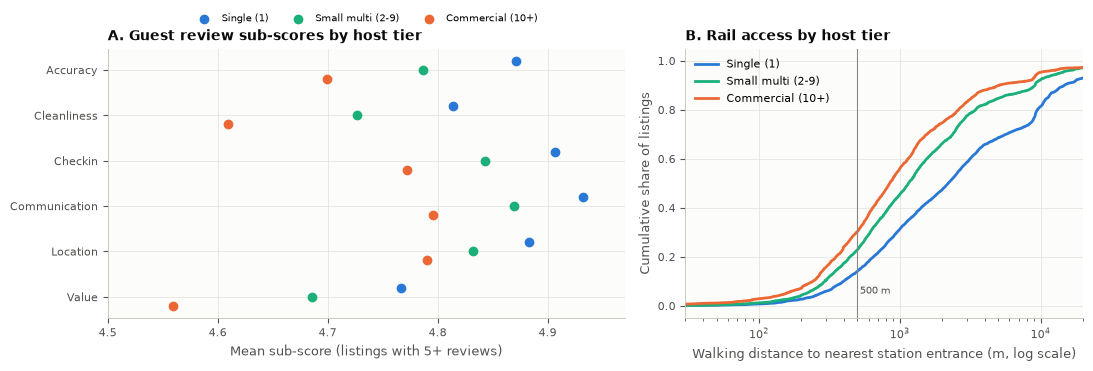

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1.3, 1]})
ax = axes[0]
subs = sub.drop(columns=["Rating"]).T
tier_colors = {"Single (1)": C1, "Small multi (2-9)": C3, "Commercial (10+)": C2}
y = np.arange(len(subs))
for t, off in zip(subs.columns, [-0.2, 0, 0.2]):
    ax.scatter(subs[t], y + off, color=tier_colors[str(t)], s=36, label=str(t), zorder=3)
ax.set_yticks(y, subs.index)
ax.invert_yaxis()
ax.set_xlabel("Mean sub-score (listings with 5+ reviews)")
ax.set_title("A. Guest review sub-scores by host tier")
ax.set_xlim(4.5, 4.97)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.06), ncols=3, fontsize=7)

ax = axes[1]
for t in ["Single (1)", "Small multi (2-9)", "Commercial (10+)"]:
    d = np.sort(df.loc[df["host_tier"] == t, "walk_dist_station_m"].values)
    ax.plot(d, np.arange(1, len(d) + 1) / len(d), color=tier_colors[t], label=t)
ax.axvline(500, color=MUTED, linewidth=0.8)
ax.text(520, 0.05, "500 m", fontsize=7, color=INK2)
ax.set_xscale("log"); ax.set_xlim(30, 20000)
ax.set_xlabel("Walking distance to nearest station entrance (m, log scale)")
ax.set_ylabel("Cumulative share of listings")
ax.set_title("B. Rail access by host tier")
ax.legend(loc="upper left")
fig.tight_layout()
savefig(fig, "a3_host_tiers")

In [32]:
t_ = pd.DataFrame(RESULTS["a3_host_tier"]).set_index("host_tier")
ht, sub_ = RESULTS["a3_host_tests"], RESULTS["a3_host_subscores"]
C_, S_ = "Commercial (10+)", "Single (1)"
widen = (ht["rating_gap_adj_ci"][1] - ht["rating_gap_adj_ci"][0]) / (ht["rating_gap_adj_ci_hc3"][1] - ht["rating_gap_adj_ci_hc3"][0])
md(f"""**Analysis 2 findings.** Commercial hosts (10+ listings) are only {t_.loc[C_, 'hosts']:.0f} hosts, yet they run {t_.loc[C_, 'listing_share_pct']:.0f}% of short-term listings. Guests rate them lower on every sub-score: the mean rating is {t_.loc[C_, 'mean_rating_5plus']:.2f} against {t_.loc[S_, 'mean_rating_5plus']:.2f} for single-listing hosts, and {t_.loc[C_, 'below_4_5_pct']:.0f}% of their listings sit below 4.5 against {t_.loc[S_, 'below_4_5_pct']:.0f}%. The largest gaps are in value ({sub_[C_]['Value']:.2f} against {sub_[S_]['Value']:.2f}) and cleanliness ({sub_[C_]['Cleanliness']:.2f} against {sub_[S_]['Cleanliness']:.2f}). The gap survives controls for room type, price, review volume, distance to the CBD and SA2: commercial listings are {abs(ht['rating_gap_adj']):.2f} stars lower ({ci_txt(*ht['rating_gap_adj_ci'], unit='', d=2)}). Clustering by host makes that interval {widen:.1f}x wider than when listings are treated as independent, but it stays far from zero.

Commercial hosts hold the best-connected stock (median walk to a station {t_.loc[C_, 'median_walk_station_m']:,.0f} m against {t_.loc[S_, 'median_walk_station_m']:,.0f} m; {t_.loc[C_, 'within_500m_pct']:.0f}% against {t_.loc[S_, 'within_500m_pct']:.0f}% within a 500 m walk). Even so, their listings book {abs(ht['occupancy_gap_adj']):.0f} fewer nights a year than comparable single-host listings in the same SA2 at the same price ({ci_txt(*ht['occupancy_gap_adj_ci'], unit=' nights', d=0)}). Better locations do not make up for a weaker guest experience. *Limitation:* ratings are observed only for listings with 5+ reviews, and guests who had a poor stay may be less likely to review, so every tier's true rating may be lower than shown.""")

**Analysis 2 findings.** Commercial hosts (10+ listings) are only 259 hosts, yet they run 38% of short-term listings. Guests rate them lower on every sub-score: the mean rating is 4.65 against 4.85 for single-listing hosts, and 22% of their listings sit below 4.5 against 4%. The largest gaps are in value (4.56 against 4.77) and cleanliness (4.61 against 4.81). The gap survives controls for room type, price, review volume, distance to the CBD and SA2: commercial listings are 0.16 stars lower (95% CI -0.19 to -0.13). Clustering by host makes that interval 2.7x wider than when listings are treated as independent, but it stays far from zero.

Commercial hosts hold the best-connected stock (median walk to a station 846 m against 2,210 m; 30% against 14% within a 500 m walk). Even so, their listings book 21 fewer nights a year than comparable single-host listings in the same SA2 at the same price (95% CI -27 nights to -15 nights). Better locations do not make up for a weaker guest experience. *Limitation:* ratings are observed only for listings with 5+ reviews, and guests who had a poor stay may be less likely to review, so every tier's true rating may be lower than shown.

## Part B – Machine learning
All three models use the same cleaned sample and the same features from the external datasets: rail access (walking distance, stations within 1 km, mode, frequency, patronage, rail time to the CBD and airport), beaches and attractions, and SEIFA. The supervised models predict **log nightly price**. Prices are strongly right-skewed, so a log target makes the errors proportional and stops luxury listings dominating the loss. Metrics are reported on the log scale (R²) and in dollars (RMSE, MAE) after back-transforming with `exp`.

**Spatial validation.** Our first draft split listings at random, so neighbours of every test listing were in the training set and the scores flattered how well the models work in a new area. We now hold out **whole SA2 neighbourhoods**: 20% of SA2s form the test set, and hyper-parameters are tuned with cross-validation folds that are also grouped by SA2. The random split is kept as a comparison, to show how optimistic it was.

In [33]:
from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold, GroupKFold, GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, silhouette_score
from xgboost import XGBRegressor

TRANSIT = ["walk_dist_station_m", "stations_within_1km", "services_per_hour", "rail_mins_to_cbd", "rail_mins_to_airport", "log_patronage"]
TRANSIT_CAT = ["nearest_mode"]
NUM = ["accommodates", "bedrooms", "beds", "bathrooms", "bath_shared", "amenities_count", "minimum_nights",
       "availability_365", "number_of_reviews", "review_scores_rating", "review_scores_location", "superhost",
       "calculated_host_listings_count", "latitude", "longitude", "dist_to_cbd_km", "dist_to_beach_km", "attractions_1km",
       "irsad_score"] + TRANSIT
CAT = ["room_type", "property_group", "neighbourhood_cleansed"] + TRANSIT_CAT

model_df = df[NUM + CAT + ["price", "sa2_code"]].copy()
model_df["log_price"] = np.log(model_df["price"])
# Ridge is linear, so give it log distances (diminishing effect of each extra metre); trees do not need this
model_df["log_walk_station"] = np.log1p(model_df["walk_dist_station_m"])
model_df["log_dist_cbd"] = np.log1p(model_df["dist_to_cbd_km"])
model_df["log_dist_beach"] = np.log1p(model_df["dist_to_beach_km"])

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
tr_i, te_i = next(gss.split(model_df, groups=model_df["sa2_code"]))
train, test = model_df.iloc[tr_i], model_df.iloc[te_i]
train_r, test_r = train_test_split(model_df, test_size=0.2, random_state=SEED)   # random split, for comparison only
y_train, y_test = train["log_price"], test["log_price"]
cv_sp = GroupKFold(n_splits=5)
RESULTS["ml_train_n"] = len(train); RESULTS["ml_test_n"] = len(test)
RESULTS["ml_test_sa2"] = int(test["sa2_code"].nunique()); RESULTS["ml_train_sa2"] = int(train["sa2_code"].nunique())

def evaluate(name, y_true_log, y_pred_log):
    yt, yp = np.exp(y_true_log), np.exp(y_pred_log)
    return {"Model": name, "R2 (log price)": r2_score(y_true_log, y_pred_log),
            "RMSE (AUD)": mean_squared_error(yt, yp) ** 0.5, "MAE (AUD)": mean_absolute_error(yt, yp),
            "MAPE %": 100 * np.mean(np.abs(yp - yt) / yt)}

# Naive baseline: predict the training median for everyone
baseline = evaluate("Baseline (median)", y_test, np.full(len(y_test), y_train.median()))
print(f"Spatial split: {len(train):,} training listings in {RESULTS['ml_train_sa2']} SA2s, {len(test):,} test listings in {RESULTS['ml_test_sa2']} other SA2s")
print(baseline)

Spatial split: 12,372 training listings in 248 SA2s, 3,314 test listings in 63 other SA2s
{'Model': 'Baseline (median)', 'R2 (log price)': -0.00011830523913447522, 'RMSE (AUD)': 369.89761505700875, 'MAE (AUD)': 208.95317139369826, 'MAPE %': np.float64(60.59256190295375)}


### Model 1 (supervised, covered in class): Ridge regression
**How it works.** Ridge is ordinary least squares with an L2 penalty (α·Σβ²) that shrinks coefficients towards zero. This stabilises the estimates when predictors are correlated. Here bedrooms, beds and guests are highly collinear, and so are latitude, longitude and the distance and rail-time measures.
**Objective.** Build an interpretable price model and measure how much rail access adds once structure and location are known.
**Preparation.** Median imputation plus missing-value indicators (unrated listings, stations without patronage data), standardisation of numeric features, one-hot encoding of room type, property group, LGA and station mode. The penalty α is tuned by 5-fold cross-validation grouped by SA2 on the training set.

In [34]:
LOGGED = {"walk_dist_station_m": "log_walk_station", "dist_to_cbd_km": "log_dist_cbd", "dist_to_beach_km": "log_dist_beach"}
NUM_R = [LOGGED.get(c, c) for c in NUM]
RAIL_R = [LOGGED.get(c, c) for c in TRANSIT]

def ridge_pipe(num_cols, cat_cols):
    pre = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)), ("sc", StandardScaler())]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=20), cat_cols)])
    return Pipeline([("pre", pre), ("model", Ridge())])

def tune_ridge(num_cols, cat_cols, tr):
    return GridSearchCV(ridge_pipe(num_cols, cat_cols), {"model__alpha": np.logspace(-2, 3, 11)}, cv=cv_sp,
                        scoring="neg_root_mean_squared_error", n_jobs=-1).fit(tr[num_cols + cat_cols], tr["log_price"], groups=tr["sa2_code"])

ridge_search = tune_ridge(NUM_R, CAT, train)
ridge = ridge_search.best_estimator_
m1 = evaluate("Model 1: Ridge", y_test, ridge.predict(test[NUM_R + CAT]))
m1_train = evaluate("Ridge (train)", y_train, ridge.predict(train[NUM_R + CAT]))
RESULTS["m1_alpha"] = float(ridge_search.best_params_["model__alpha"])
RESULTS["m1_cv_rmse_log"] = round(-ridge_search.best_score_, 4)
RESULTS["m1"] = {k: (round(v, 4) if isinstance(v, float) else v) for k, v in m1.items()}
RESULTS["m1_train_r2"] = round(m1_train["R2 (log price)"], 4)

# Ablation: the same model without any rail feature (shows what the rail datasets add)
NUM_R_noT = [c for c in NUM_R if c not in RAIL_R]; CAT_noT = [c for c in CAT if c not in TRANSIT_CAT]
r_noT = tune_ridge(NUM_R_noT, CAT_noT, train)
m1_noT = evaluate("Ridge without rail features", y_test, r_noT.predict(test[NUM_R_noT + CAT_noT]))
RESULTS["m1_noT"] = {k: (round(v, 4) if isinstance(v, float) else v) for k, v in m1_noT.items()}
# Random-split comparison with the same alpha
ridge_rand = clone(ridge).fit(train_r[NUM_R + CAT], train_r["log_price"])
m1_rand = evaluate("Ridge (random split)", test_r["log_price"], ridge_rand.predict(test_r[NUM_R + CAT]))
RESULTS["m1_random"] = {k: (round(v, 4) if isinstance(v, float) else v) for k, v in m1_rand.items()}

# Standardised coefficients
feat_names = ridge.named_steps["pre"].get_feature_names_out()
coefs = pd.Series(ridge.named_steps["model"].coef_, index=feat_names)
coefs.index = coefs.index.str.replace("num__", "").str.replace("cat__", "")
RESULTS["m1_coef_rail"] = {k: round(coefs[k], 4) for k in coefs.index if k in RAIL_R or k.startswith("nearest_mode")}
RESULTS["m1_top_coefs"] = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(12).round(4).to_dict()
_nl = coefs[~coefs.index.str.startswith("neighbourhood_cleansed")]
RESULTS["m1_top_nonlga"] = _nl.reindex(_nl.abs().sort_values(ascending=False).index).head(12).round(4).to_dict()
RESULTS["m1_coef_cbd"] = round(coefs["log_dist_cbd"], 4)
print(f"Best alpha = {RESULTS['m1_alpha']}")
pd.DataFrame([baseline, m1_train, m1, m1_noT, m1_rand]).round(3)

Best alpha = 100.0


,Model,R2 (log price),RMSE (AUD),MAE (AUD),MAPE %
0,Baseline (median),-0.000,369.898,208.953,60.593
1,Ridge (train),0.736,232.485,117.445,27.106
2,Model 1: Ridge,0.720,245.354,120.911,27.820
3,Ridge without rail features,0.709,243.203,122.667,28.439
4,Ridge (random split),0.735,235.189,117.973,26.840


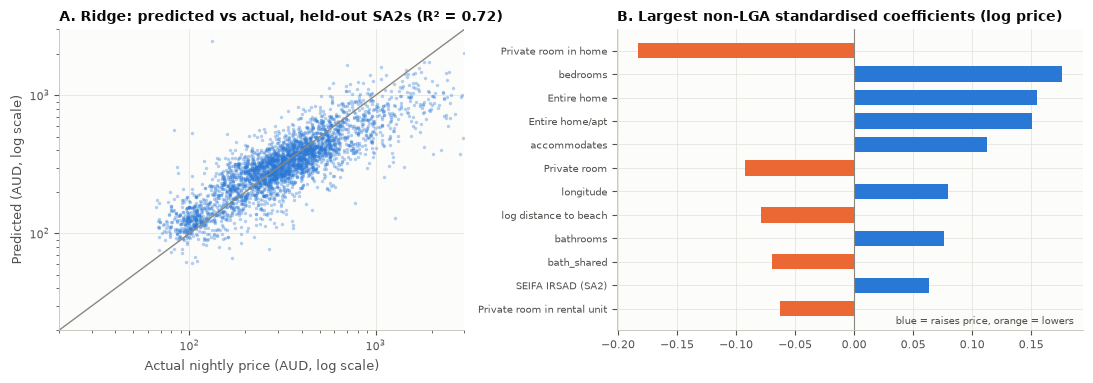

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), gridspec_kw={"width_ratios": [1, 1.15]})
ax = axes[0]
pred = ridge.predict(test[NUM_R + CAT])
ax.scatter(np.exp(y_test), np.exp(pred), s=6, alpha=0.35, color=C1, linewidths=0)
lims = [20, 3000]
ax.plot(lims, lims, color=MUTED, linewidth=1)
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual nightly price (AUD, log scale)"); ax.set_ylabel("Predicted (AUD, log scale)")
ax.set_title(f"A. Ridge: predicted vs actual, held-out SA2s (R² = {m1['R2 (log price)']:.2f})")
ax = axes[1]
READABLE = {"room_type_infrequent_sklearn": "Shared room (rare, merged)", "room_type_Hotel room": "Hotel room", "room_type_Entire home/apt": "Entire home/apt",
            "room_type_Private room": "Private room", "log_walk_station": "log walking distance to station (rail)",
            "stations_within_1km": "stations within 1 km (rail)", "log_dist_cbd": "log distance to CBD", "log_dist_beach": "log distance to beach",
            "rail_mins_to_cbd": "rail minutes to CBD (rail)", "rail_mins_to_airport": "rail minutes to airport (rail)",
            "services_per_hour": "services per hour (rail)", "log_patronage": "station patronage (rail)", "irsad_score": "SEIFA IRSAD (SA2)"}
non_lga = coefs[~coefs.index.str.startswith("neighbourhood_cleansed")]
top = non_lga.reindex(non_lga.abs().sort_values(ascending=False).index).head(12)[::-1]
top.index = [READABLE.get(i, i.replace("property_group_", "").replace("missingindicator_", "missing: ").replace("nearest_mode_", "nearest mode: ")) for i in top.index]
ax.barh(top.index, top.values, color=[C2 if v < 0 else C1 for v in top.values], height=0.65)
ax.axvline(0, color=MUTED, linewidth=0.8)
ax.set_title("B. Largest non-LGA standardised coefficients (log price)")
ax.tick_params(axis="y", labelsize=7)
ax.text(0.98, 0.02, "blue = raises price, orange = lowers", transform=ax.transAxes, ha="right", fontsize=7, color=INK2)
fig.tight_layout()
savefig(fig, "m1_ridge")

In [36]:
md(f"""**Model 1 – results.** On SA2 neighbourhoods it never saw in training, Ridge explains {RESULTS['m1']['R2 (log price)']:.1%} of the variation in log price (RMSE ${RESULTS['m1']['RMSE (AUD)']:,.0f}, MAE ${RESULTS['m1']['MAE (AUD)']:,.0f}, MAPE {RESULTS['m1']['MAPE %']:.0f}%), against {RESULTS['m1_train_r2']:.1%} on the training data, so it barely overfits. The largest effects are listing structure (private rooms, bedrooms, entire homes), then location: distance to the beach, longitude (east is dearer) and neighbourhood advantage (SEIFA). Removing all rail features lowers test R² from {RESULTS['m1']['R2 (log price)']:.3f} to {RESULTS['m1_noT']['R2 (log price)']:.3f}.

**Issues encountered and how we handled them.**
- *Skewed target:* nightly price is strongly right-skewed (the raw maximum was over $50,000). Modelling log price makes the errors proportional and lets coefficients be read as approximate percentage effects.
- *Optimistic validation:* with a random split Ridge scores R² = {RESULTS['m1_random']['R2 (log price)']:.3f}; holding out whole SA2s gives {RESULTS['m1']['R2 (log price)']:.3f}. The random split rewarded the model for having seen each test listing's neighbours, so we report the spatial result.
- *Missing values:* 12% of listings have no review scores and a few stations have no patronage record. Median imputation plus missing-value indicators keeps them in the model, and the indicators capture the "unreviewed" effect.
- *Rare categories:* only {(df['room_type'] == 'Shared room').sum()} shared rooms (and {(df['room_type'] == 'Hotel room').sum()} hotel rooms) remain after cleaning. `min_frequency=20` merges categories with fewer than 20 training rows into one infrequent level.
- *Collinearity:* LGA dummies, coordinates, distances and rail times carry overlapping information, so individual location coefficients should not be read on their own. The L2 penalty (α = {RESULTS['m1_alpha']:g}, chosen by grouped cross-validation) keeps predictions stable.
- *Limitations:* the model is linear and additive (no interactions), and listed price is an asking price, not the price paid.""")

**Model 1 – results.** On SA2 neighbourhoods it never saw in training, Ridge explains 72.0% of the variation in log price (RMSE $245, MAE $121, MAPE 28%), against 73.6% on the training data, so it barely overfits. The largest effects are listing structure (private rooms, bedrooms, entire homes), then location: distance to the beach, longitude (east is dearer) and neighbourhood advantage (SEIFA). Removing all rail features lowers test R² from 0.720 to 0.709.

**Issues encountered and how we handled them.**
- *Skewed target:* nightly price is strongly right-skewed (the raw maximum was over $50,000). Modelling log price makes the errors proportional and lets coefficients be read as approximate percentage effects.
- *Optimistic validation:* with a random split Ridge scores R² = 0.735; holding out whole SA2s gives 0.720. The random split rewarded the model for having seen each test listing's neighbours, so we report the spatial result.
- *Missing values:* 12% of listings have no review scores and a few stations have no patronage record. Median imputation plus missing-value indicators keeps them in the model, and the indicators capture the "unreviewed" effect.
- *Rare categories:* only 13 shared rooms (and 49 hotel rooms) remain after cleaning. `min_frequency=20` merges categories with fewer than 20 training rows into one infrequent level.
- *Collinearity:* LGA dummies, coordinates, distances and rail times carry overlapping information, so individual location coefficients should not be read on their own. The L2 penalty (α = 100, chosen by grouped cross-validation) keeps predictions stable.
- *Limitations:* the model is linear and additive (no interactions), and listed price is an asking price, not the price paid.

### Model 2 (unsupervised, covered in class): K-Means market segmentation
**How it works.** K-Means assigns each listing to the nearest of *k* centroids, then moves each centroid to the mean of its members. It repeats until assignments stop changing, which minimises within-cluster squared distance (inertia).
**Objective.** Segment Sydney's short-term rental supply into zones that combine location, price, rail access and demand, as a starting point for investment screening.
**Variables.** Latitude, longitude, log price, log walking distance to a station, distance to CBD, distance to the beach and estimated occupancy, all standardised so no single unit dominates. *k* is chosen with the elbow curve and the silhouette score (computed on a 4,000-listing random sample, because silhouette is O(n²)).

In [37]:
KM_FEATS = ["latitude", "longitude", "log_price", "log_walk_station", "dist_to_cbd_km", "log_dist_beach", "estimated_occupancy_l365d"]
km_df = df[["latitude", "longitude", "price", "walk_dist_station_m", "dist_to_cbd_km", "dist_to_beach_km", "estimated_occupancy_l365d"]].copy()
km_df["log_price"] = np.log(km_df["price"]); km_df["log_walk_station"] = np.log1p(km_df["walk_dist_station_m"])
km_df["log_dist_beach"] = np.log1p(km_df["dist_to_beach_km"])
Xk = StandardScaler().fit_transform(km_df[KM_FEATS])
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(Xk), 4000, replace=False)
k_rows = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(Xk)
    k_rows.append({"k": k, "inertia": km.inertia_, "silhouette": silhouette_score(Xk[sample_idx], km.labels_[sample_idx])})
k_tab = pd.DataFrame(k_rows)
RESULTS["m2_k_table"] = k_tab.round(4).to_dict(orient="list")
k_tab.round(3)

,k,inertia,silhouette
0,2,83286.196,0.282
1,3,65192.582,0.263
2,4,56539.686,0.238
3,5,49862.184,0.236
4,6,44155.529,0.241
5,7,41113.631,0.247
6,8,38461.590,0.242
7,9,36377.382,0.211
8,10,34074.387,0.220


In [38]:
# Choose k: highest silhouette among k >= 4 (k = 2-3 only splits city vs suburbs, which is too coarse to act on)
best_k = int(k_tab.loc[k_tab["k"] >= 4].sort_values("silhouette", ascending=False).iloc[0]["k"])
km = KMeans(n_clusters=best_k, n_init=20, random_state=SEED).fit(Xk)
df["cluster"] = km.labels_
RESULTS["m2_k"] = best_k
RESULTS["m2_silhouette"] = round(float(k_tab.set_index("k").loc[best_k, "silhouette"]), 4)

prof = df.groupby("cluster").agg(listings=("id", "size"), median_price=("price", "median"),
                                 median_occupancy=("estimated_occupancy_l365d", "median"),
                                 median_revenue=("estimated_revenue_l365d", "median"),
                                 median_walk_station_m=("walk_dist_station_m", "median"),
                                 median_dist_cbd_km=("dist_to_cbd_km", "median"),
                                 median_dist_beach_km=("dist_to_beach_km", "median"),
                                 entire_home_pct=("room_type", lambda s: 100 * (s == "Entire home/apt").mean()),
                                 mean_rating=("review_scores_rating", "mean"),
                                 top_lga=("neighbourhood_cleansed", lambda s: ", ".join(s.value_counts().head(2).index)))
prof = prof.sort_values("median_dist_cbd_km")
# Name each segment from its profile (ring, coast, price level, demand level, rail access), so names stay correct if k changes
med_p, med_o = df["price"].median(), df["estimated_occupancy_l365d"].median()
def seg_name(p):
    ring = "Inner" if p.median_dist_cbd_km < 5 else ("Middle" if p.median_dist_cbd_km < 20 else "Outer")
    coast = " coastal" if p.median_dist_beach_km < 1.5 else ""
    price = "premium" if p.median_price > 1.3 * med_p else ("budget" if p.median_price < 0.85 * med_p else "mid-price")
    dem = "high-turnover" if p.median_occupancy > 1.5 * med_o else ("low-utilisation" if p.median_occupancy < 0.75 * med_o else "average demand")
    rail = "rail-served" if p.median_walk_station_m < 1000 else "rail-remote"
    return f"{ring}{coast}: {price}, {dem}, {rail}"
names = prof.apply(seg_name, axis=1)
dup = names.duplicated(keep=False)
names[dup] = names[dup] + " (" + (names[dup].groupby(names[dup]).cumcount() + 1).astype(str) + ")"
prof.insert(0, "segment", names)
RESULTS["m2_profiles"] = prof.round(1).reset_index().to_dict(orient="list")
prof.round(1)

,segment,listings,median_price,median_occupancy,median_revenue,median_walk_station_m,median_dist_cbd_km,median_dist_beach_km,entire_home_pct,mean_rating,top_lga
cluster,,,,,,,,,,,
4,"Inner: mid-price, high-turnover, rail-served",2694,280.0,210.0,55858.5,628.5,2.8,2.9,86.2,4.8,"Sydney, Waverley"
0,"Inner: mid-price, low-utilisation, rail-served",4592,293.2,30.0,7572.0,558.5,3.0,3.3,77.9,4.7,"Sydney, Randwick"
3,"Middle coastal: premium, low-utilisation, rail...",3375,436.0,30.0,14796.0,3684.1,7.3,0.6,93.5,4.8,"Waverley, Manly"
5,"Middle: budget, low-utilisation, rail-served",2594,238.7,30.0,6237.0,988.3,14.4,8.6,62.9,4.6,"Auburn, Parramatta"
6,"Outer: budget, average demand, rail-remote",780,251.8,48.0,9814.0,3545.5,27.2,5.3,70.4,4.7,"Liverpool, Sutherland Shire"
2,"Outer coastal: premium, low-utilisation, rail-...",881,635.0,24.0,16206.0,28150.4,28.1,0.6,95.6,4.9,"Pittwater, Warringah"
1,"Outer: mid-price, average demand, rail-remote",770,277.1,38.0,10191.0,2468.6,36.5,16.9,68.4,4.7,"Blacktown, The Hills Shire"


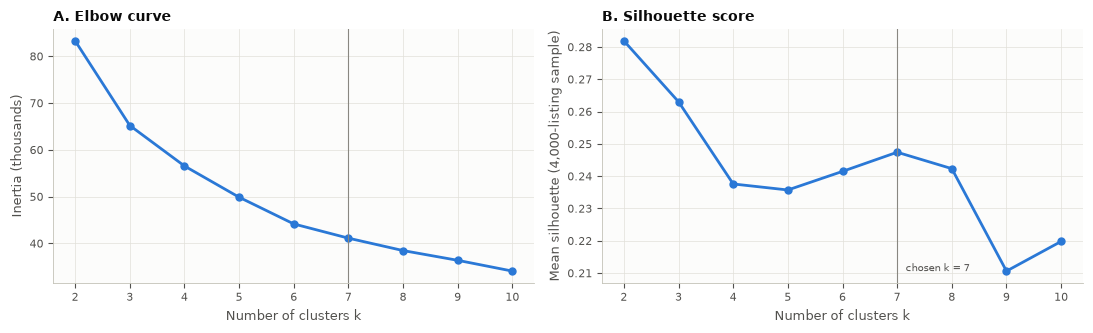

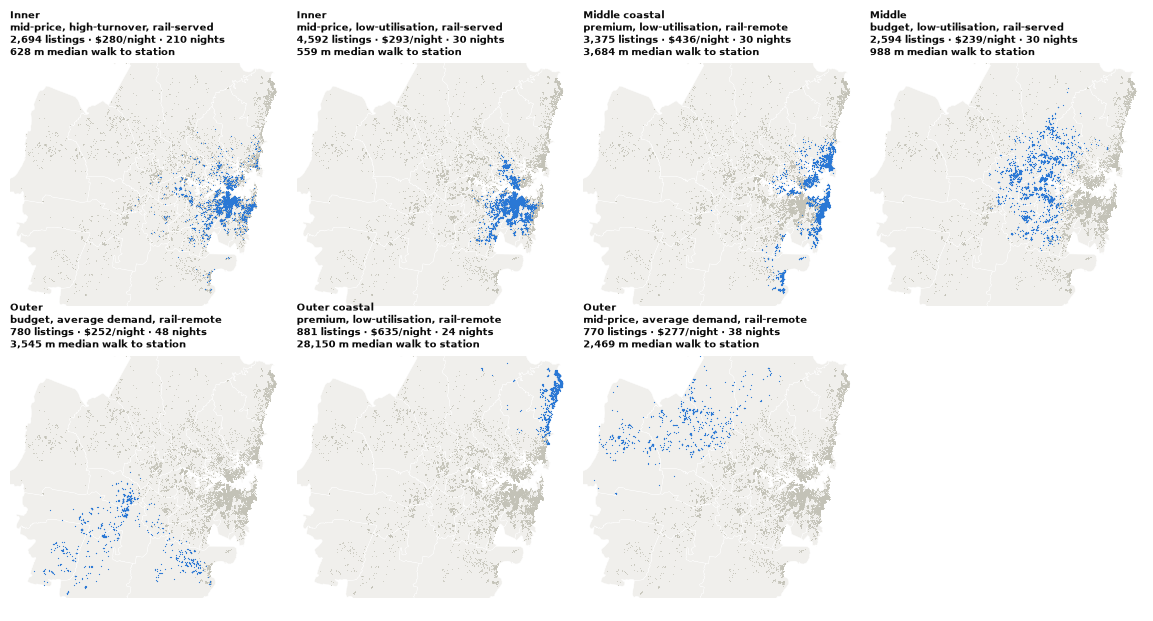

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(k_tab["k"], k_tab["inertia"] / 1000, color=C1, marker="o", markersize=5)
axes[0].axvline(best_k, color=MUTED, linewidth=0.8)
axes[0].set_xlabel("Number of clusters k"); axes[0].set_ylabel("Inertia (thousands)")
axes[0].set_title("A. Elbow curve")
axes[1].plot(k_tab["k"], k_tab["silhouette"], color=C1, marker="o", markersize=5)
axes[1].axvline(best_k, color=MUTED, linewidth=0.8)
axes[1].text(best_k + 0.1, k_tab["silhouette"].min(), f" chosen k = {best_k}", fontsize=7, color=INK2)
axes[1].set_xlabel("Number of clusters k"); axes[1].set_ylabel("Mean silhouette (4,000-listing sample)")
axes[1].set_title("B. Silhouette score")
fig.tight_layout()
savefig(fig, "m2_choose_k")

# Small multiples: one panel per cluster (avoids needing more than 3 distinguishable colours on a map)
order = prof.index.tolist()
ncol = min(best_k, 4); nrow = int(np.ceil(best_k / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(2.9 * ncol, 3.1 * nrow), squeeze=False)
for ax, c in zip(axes.flat, order):
    lga_shapes.plot(ax=ax, color="#f0efec", edgecolor="white", linewidth=0.3)
    ax.scatter(df["longitude"], df["latitude"], s=0.3, color="#c3c2b7", linewidths=0)
    sel = df[df["cluster"] == c]
    ax.scatter(sel["longitude"], sel["latitude"], s=0.8, color=C1, linewidths=0)
    p = prof.loc[c]
    ax.set_title(f"{p.segment.replace(': ', chr(10))}\n{int(p.listings):,} listings · ${p.median_price:,.0f}/night · {p.median_occupancy:.0f} nights\n"
                 f"{p.median_walk_station_m:,.0f} m median walk to station", fontsize=7)
    ax.set_xlim(150.6, 151.36); ax.set_ylim(-34.12, -33.56); ax.set_axis_off()
for ax in list(axes.flat)[best_k:]:
    ax.set_axis_off()
fig.tight_layout()
savefig(fig, "m2_cluster_maps")

In [40]:
kt = pd.DataFrame(RESULTS["m2_k_table"]).set_index("k")
pf = pd.DataFrame(RESULTS["m2_profiles"])
top_rev = pf.sort_values("median_revenue", ascending=False).iloc[0]
seg_lines = "\n".join(f"- **{r.segment}** ({int(r.listings):,} listings; mainly {r.top_lga}): ${r.median_price:,.0f}/night, {r.median_occupancy:.0f} nights a year, median revenue ${r.median_revenue:,.0f}, {r.median_walk_station_m:,.0f} m walk to a station."
                       for r in pf.itertuples())
md(f"""**Model 2 – results.** With k = {RESULTS['m2_k']} the segments are:

{seg_lines}

The segment that earns the most ({top_rev.segment}, median revenue ${top_rev.median_revenue:,.0f}) is not the dearest; it wins on nights booked. Rail-served segments include both the busiest stock and some of the least used, which matches Analysis 1: being near rail does not by itself fill the calendar.

**Issues encountered and how we handled them.**
- *Runtime:* silhouette is O(n²). On {len(df):,} listings it is expensive to repeat for nine values of k, so it is computed on a fixed random sample of 4,000 listings.
- *Choice of k:* the silhouette is highest at k = 2 ({kt.loc[2, 'silhouette']:.2f}), but that only separates the city from everything else. Among k ≥ 4 it peaks at k = {RESULTS['m2_k']} ({RESULTS['m2_silhouette']:.2f}) and the elbow has flattened by then, so we use k = {RESULTS['m2_k']}.
- *Naming:* segment names are generated from each segment's profile (ring, beach, price and demand relative to the city median, walk to rail), so they stay accurate if the data or k change.
- *Scaling:* the features are on very different scales (occupancy 0–255 nights against coordinates that vary by fractions of a degree), so all features are z-scored first.
- *Limitations:* K-Means assumes round, equally sized clusters, and silhouettes around {RESULTS['m2_silhouette']:.2f} mean the segments overlap. Latitude and longitude are treated as Euclidean. The segments are a screening tool, not natural market boundaries.""")

**Model 2 – results.** With k = 7 the segments are:

- **Inner: mid-price, high-turnover, rail-served** (2,694 listings; mainly Sydney, Waverley): $280/night, 210 nights a year, median revenue $55,858, 628 m walk to a station.
- **Inner: mid-price, low-utilisation, rail-served** (4,592 listings; mainly Sydney, Randwick): $293/night, 30 nights a year, median revenue $7,572, 558 m walk to a station.
- **Middle coastal: premium, low-utilisation, rail-remote** (3,375 listings; mainly Waverley, Manly): $436/night, 30 nights a year, median revenue $14,796, 3,684 m walk to a station.
- **Middle: budget, low-utilisation, rail-served** (2,594 listings; mainly Auburn, Parramatta): $239/night, 30 nights a year, median revenue $6,237, 988 m walk to a station.
- **Outer: budget, average demand, rail-remote** (780 listings; mainly Liverpool, Sutherland Shire): $252/night, 48 nights a year, median revenue $9,814, 3,546 m walk to a station.
- **Outer coastal: premium, low-utilisation, rail-remote** (881 listings; mainly Pittwater, Warringah): $635/night, 24 nights a year, median revenue $16,206, 28,150 m walk to a station.
- **Outer: mid-price, average demand, rail-remote** (770 listings; mainly Blacktown, The Hills Shire): $277/night, 38 nights a year, median revenue $10,191, 2,469 m walk to a station.

The segment that earns the most (Inner: mid-price, high-turnover, rail-served, median revenue $55,858) is not the dearest; it wins on nights booked. Rail-served segments include both the busiest stock and some of the least used, which matches Analysis 1: being near rail does not by itself fill the calendar.

**Issues encountered and how we handled them.**
- *Runtime:* silhouette is O(n²). On 15,686 listings it is expensive to repeat for nine values of k, so it is computed on a fixed random sample of 4,000 listings.
- *Choice of k:* the silhouette is highest at k = 2 (0.28), but that only separates the city from everything else. Among k ≥ 4 it peaks at k = 7 (0.25) and the elbow has flattened by then, so we use k = 7.
- *Naming:* segment names are generated from each segment's profile (ring, beach, price and demand relative to the city median, walk to rail), so they stay accurate if the data or k change.
- *Scaling:* the features are on very different scales (occupancy 0–255 nights against coordinates that vary by fractions of a degree), so all features are z-scored first.
- *Limitations:* K-Means assumes round, equally sized clusters, and silhouettes around 0.25 mean the segments overlap. Latitude and longitude are treated as Euclidean. The segments are a screening tool, not natural market boundaries.

### Model 3 (not covered in class): XGBoost regressor with SHAP interpretation
**How it works.** XGBoost (Chen & Guestrin, 2016) builds an ensemble of shallow decision trees by gradient boosting. Each new tree is fitted to the residual errors of the trees so far, and its contribution is scaled by a learning rate. Regularisation (L2 on leaf weights, minimum child weight, row and column subsampling) controls overfitting. Unlike Ridge, it captures non-linear effects and interactions, such as rail access mattering more in some areas than others, without these being specified by hand.
**Interpretation.** SHAP (Lundberg & Lee, 2017) splits each prediction into additive feature contributions based on Shapley values from cooperative game theory. Because the target is log price, a SHAP value *s* means the feature changes the predicted price by about `exp(s) - 1` per cent.
**Objective.** Improve on Ridge's predictive accuracy and isolate the non-linear contribution of rail access to price.
**Tuning.** Randomised search (30 candidates, 3-fold cross-validation grouped by SA2 on the training set) over depth, learning rate, number of trees, subsampling and regularisation. The model without rail features gets its own search, so the comparison is fair.

In [41]:
def xgb_pipe(num_cols, cat_cols, **params):
    pre = ColumnTransformer([("num", "passthrough", num_cols),
                             ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse_output=False), cat_cols)])
    return Pipeline([("pre", pre), ("model", XGBRegressor(tree_method="hist", random_state=SEED, n_jobs=-1, **params))])

param_dist = {"model__n_estimators": [300, 500, 800, 1200], "model__max_depth": [4, 5, 6, 8],
              "model__learning_rate": [0.02, 0.03, 0.05, 0.08], "model__subsample": [0.7, 0.8, 0.9],
              "model__colsample_bytree": [0.6, 0.8, 1.0], "model__min_child_weight": [1, 3, 5, 10],
              "model__reg_lambda": [0.5, 1, 3, 10]}
def tune_xgb(num_cols, cat_cols, tr):
    return RandomizedSearchCV(xgb_pipe(num_cols, cat_cols), param_dist, n_iter=30, cv=GroupKFold(n_splits=3),
                              scoring="neg_root_mean_squared_error", random_state=SEED, n_jobs=1).fit(
                                  tr[num_cols + cat_cols], tr["log_price"], groups=tr["sa2_code"])
t0 = time.time()
xgb_search = tune_xgb(NUM, CAT, train)
xgb = xgb_search.best_estimator_
RESULTS["m3_search_seconds"] = round(time.time() - t0, 1)
m3 = evaluate("Model 3: XGBoost", y_test, xgb.predict(test[NUM + CAT]))
m3_train = evaluate("XGBoost (train)", y_train, xgb.predict(train[NUM + CAT]))
RESULTS["m3_params"] = {k.replace("model__", ""): v for k, v in xgb_search.best_params_.items()}
RESULTS["m3_cv_rmse_log"] = round(-xgb_search.best_score_, 4)
RESULTS["m3"] = {k: (round(v, 4) if isinstance(v, float) else v) for k, v in m3.items()}
RESULTS["m3_train_r2"] = round(m3_train["R2 (log price)"], 4)

# Ablation without rail features, re-tuned from scratch
NUM_noT = [c for c in NUM if c not in TRANSIT]
xgb_noT = tune_xgb(NUM_noT, CAT_noT, train).best_estimator_
m3_noT = evaluate("XGBoost without rail features", y_test, xgb_noT.predict(test[NUM_noT + CAT_noT]))
RESULTS["m3_noT"] = {k: (round(v, 4) if isinstance(v, float) else v) for k, v in m3_noT.items()}
# Random-split comparison with the same hyper-parameters
xgb_rand = clone(xgb).fit(train_r[NUM + CAT], train_r["log_price"])
m3_rand = evaluate("XGBoost (random split)", test_r["log_price"], xgb_rand.predict(test_r[NUM + CAT]))
RESULTS["m3_random"] = {k: (round(v, 4) if isinstance(v, float) else v) for k, v in m3_rand.items()}

compare = pd.DataFrame([baseline, m1, m1_noT, m3, m3_noT, m1_rand, m3_rand])
compare.to_csv(OUT / "model_comparison.csv", index=False)
print("Best parameters:", RESULTS["m3_params"])
compare.round(3)

Best parameters: {'subsample': 0.8, 'reg_lambda': 10, 'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.02, 'colsample_bytree': 0.6}


,Model,R2 (log price),RMSE (AUD),MAE (AUD),MAPE %
0,Baseline (median),-0.000,369.898,208.953,60.593
1,Model 1: Ridge,0.720,245.354,120.911,27.820
2,Ridge without rail features,0.709,243.203,122.667,28.439
3,Model 3: XGBoost,0.786,206.327,104.198,23.964
4,XGBoost without rail features,0.786,207.363,104.631,23.920
5,Ridge (random split),0.735,235.189,117.973,26.840
6,XGBoost (random split),0.805,196.368,99.906,22.696


In [42]:
# SHAP values on the test set
import shap
pre = xgb.named_steps["pre"]; booster_model = xgb.named_steps["model"]
X_test_t = pre.transform(test[NUM + CAT])
names_t = [n.replace("num__", "").replace("cat__", "") for n in pre.get_feature_names_out()]
explainer = shap.TreeExplainer(booster_model)
shap_vals = explainer.shap_values(X_test_t)
shap_df = pd.DataFrame(shap_vals, columns=names_t, index=test.index)

# Group one-hot columns back to their original variable
def base_name(n):
    for c in CAT:
        if n.startswith(c + "_"):
            return c
    return n
grouped = shap_df.abs().T.groupby(base_name).sum().T.mean().sort_values(ascending=False)
RESULTS["m3_shap_mean_abs"] = grouped.round(4).to_dict()
RAIL_ALL = TRANSIT + TRANSIT_CAT
rail_share = grouped[RAIL_ALL].sum() / grouped.sum()
RESULTS["m3_shap_rail_share_pct"] = pct(rail_share)
RESULTS["m3_shap_rail_rank"] = int(min(grouped.index.get_loc(c) for c in RAIL_ALL)) + 1
RESULTS["m3_shap_rail_top"] = grouped[RAIL_ALL].sort_values(ascending=False).index[0]

# Average price effect of walking distance by band (from SHAP, in % terms), overall and by CBD ring
sd = pd.DataFrame({"dist": test["walk_dist_station_m"], "shap": shap_df["walk_dist_station_m"],
                   "ring": df.loc[test.index, "cbd_ring"].astype(str)})
sd["band"] = pd.cut(sd["dist"], [0, 250, 500, 1000, 2000, 5000, np.inf],
                    labels=["<250 m", "250-500 m", "500 m-1 km", "1-2 km", "2-5 km", ">5 km"])
shap_band = sd.groupby("band", observed=True)["shap"].mean().apply(lambda s: 100 * (np.exp(s) - 1))
RESULTS["m3_shap_dist_band_pct"] = shap_band.round(2).to_dict()
shap_ring = sd.groupby(["ring", "band"], observed=True)["shap"].mean().apply(lambda s: 100 * (np.exp(s) - 1)).unstack()
RESULTS["m3_shap_ring_band_pct"] = shap_ring.round(2).to_dict(orient="index")
display(shap_ring.round(2))
grouped.head(15)

band,<250 m,250-500 m,500 m-1 km,1-2 km,2-5 km,>5 km
ring,,,,,,
Inner (<5 km),-0.54,-0.84,-0.27,-0.41,-0.16,NaN
Middle (5-15 km),-0.74,-1.12,-0.53,-0.45,-0.13,1.27
Outer (>15 km),0.22,-0.84,-0.44,-0.54,-0.77,2.85


bedrooms                          0.171107
accommodates                      0.132854
room_type                         0.115450
bathrooms                         0.057628
longitude                         0.054611
dist_to_beach_km                  0.049418
property_group                    0.047093
amenities_count                   0.036824
irsad_score                       0.034746
minimum_nights                    0.033952
number_of_reviews                 0.032500
review_scores_location            0.029860
review_scores_rating              0.028880
availability_365                  0.027179
calculated_host_listings_count    0.025578
dtype: float32

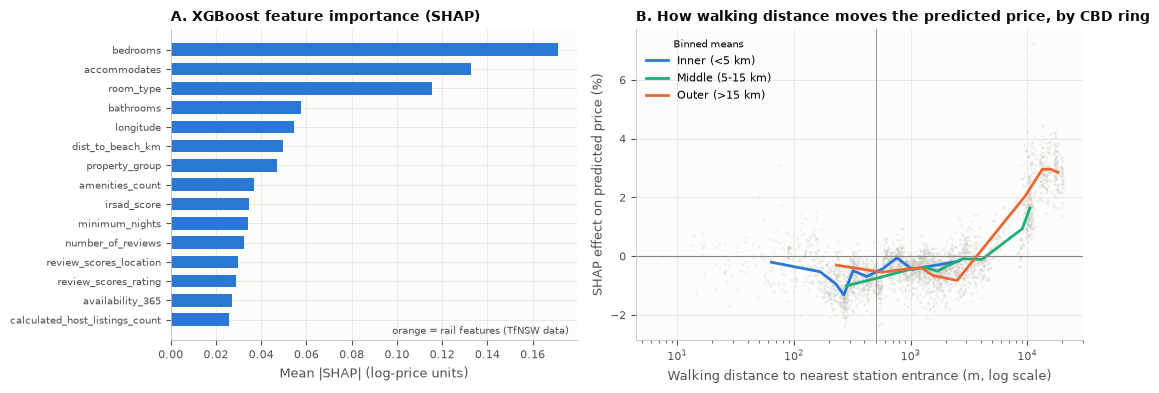

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), gridspec_kw={"width_ratios": [1, 1.1]})
ax = axes[0]
top = grouped.head(15)[::-1]
ax.barh(top.index, top.values, color=[C2 if i in RAIL_ALL else C1 for i in top.index], height=0.65)
ax.set_xlabel("Mean |SHAP| (log-price units)")
ax.set_title("A. XGBoost feature importance (SHAP)")
ax.tick_params(axis="y", labelsize=7)
ax.text(0.98, 0.02, "orange = rail features (TfNSW data)", transform=ax.transAxes, ha="right", fontsize=7, color=INK2)

ax = axes[1]
ax.scatter(sd["dist"], 100 * (np.exp(sd["shap"]) - 1), s=4, alpha=0.2, color="#c3c2b7", linewidths=0)
for ring_name, col in zip(["Inner (<5 km)", "Middle (5-15 km)", "Outer (>15 km)"], [C1, C3, C2]):
    r = sd[sd["ring"] == ring_name]
    if len(r) < 100:
        continue
    b = r.assign(b=pd.qcut(np.log(r["dist"]), 10, duplicates="drop")).groupby("b", observed=True).agg(d=("dist", "median"), s=("shap", "mean"))
    ax.plot(b["d"], 100 * (np.exp(b["s"]) - 1), color=col, linewidth=2, label=ring_name)
ax.axhline(0, color=MUTED, linewidth=0.8)
ax.axvline(500, color=MUTED, linewidth=0.6)
ax.set_xscale("log")
ax.set_xlabel("Walking distance to nearest station entrance (m, log scale)")
ax.set_ylabel("SHAP effect on predicted price (%)")
ax.set_title("B. How walking distance moves the predicted price, by CBD ring")
ax.legend(loc="upper left", title="Binned means", title_fontsize=7)
fig.tight_layout()
savefig(fig, "m3_shap")

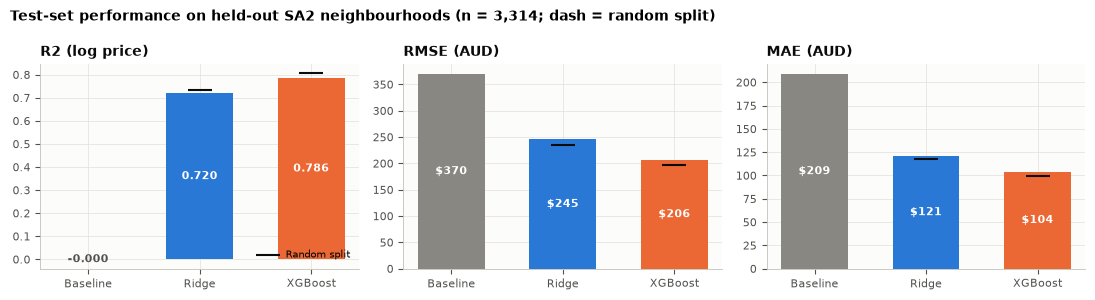

In [44]:
# Model comparison chart: spatial hold-out (main) with the random split shown for comparison
fig, axes = plt.subplots(1, 3, figsize=(11, 3.0))
show = compare.set_index("Model").loc[["Baseline (median)", "Model 1: Ridge", "Model 3: XGBoost"]]
rand = compare.set_index("Model").loc[["Ridge (random split)", "XGBoost (random split)"]]
labels = ["Baseline", "Ridge", "XGBoost"]
for ax, col, fmt in [(axes[0], "R2 (log price)", "{:.3f}"), (axes[1], "RMSE (AUD)", "${:,.0f}"), (axes[2], "MAE (AUD)", "${:,.0f}")]:
    bars = ax.bar(labels, show[col], color=[MUTED, C1, C2], width=0.6)
    for b, v in zip(bars, show[col]):
        ax.text(b.get_x() + b.get_width() / 2, max(b.get_height(), 0) / 2, fmt.format(v), ha="center", va="center", fontsize=8,
                color="white" if v > 0.1 * show[col].max() else INK2, fontweight="bold")
    ax.scatter([1, 2], rand[col], marker="_", s=300, color=INK, linewidths=1.5, zorder=3, label="Random split")
    ax.set_title(col)
axes[0].legend(loc="lower right", fontsize=7)
fig.suptitle("Test-set performance on held-out SA2 neighbourhoods (n = {:,}; dash = random split)".format(len(test)), x=0.01, ha="left", fontsize=10, fontweight="bold")
fig.tight_layout()
savefig(fig, "ml_comparison")

### Error analysis – where do the models miss?

In [45]:
err = df.loc[test.index, ["room_type", "neighbourhood_cleansed"]].copy()
err["actual"] = np.exp(y_test)
err["ridge"] = np.exp(ridge.predict(test[NUM_R + CAT])); err["xgb"] = np.exp(xgb.predict(test[NUM + CAT]))
err["price_band"] = pd.qcut(err["actual"], 4, labels=["Q1 (cheapest)", "Q2", "Q3", "Q4 (dearest)"])
err_tab = err.groupby("price_band", observed=True).apply(
    lambda g: pd.Series({"Ridge MAPE %": 100 * np.mean(np.abs(g.ridge - g.actual) / g.actual),
                         "XGBoost MAPE %": 100 * np.mean(np.abs(g.xgb - g.actual) / g.actual),
                         "XGBoost bias %": 100 * np.mean((g.xgb - g.actual) / g.actual)}))
RESULTS["ml_err_by_band"] = err_tab.round(2).to_dict()
err_tab.round(1)

,Ridge MAPE %,XGBoost MAPE %,XGBoost bias %
price_band,,,
Q1 (cheapest),38.1,29.3,22.9
Q2,23.4,21.2,8.4
Q3,19.5,18.5,-2.2
Q4 (dearest),30.3,26.8,-15.7


In [46]:
sb = RESULTS["m3_shap_dist_band_pct"]
max_near = shap_ring.drop(columns=">5 km").abs().max().max()
far = df[df["walk_dist_station_m"] > 5000]
RESULTS["far_from_rail_coastal_pct"] = pct((far["dist_to_beach_km"] < 2).mean())
md(f"""**Model 3 – results.** On held-out SA2s XGBoost explains {RESULTS['m3']['R2 (log price)']:.1%} of the variation in log price (RMSE ${RESULTS['m3']['RMSE (AUD)']:,.0f}, MAE ${RESULTS['m3']['MAE (AUD)']:,.0f}, MAPE {RESULTS['m3']['MAPE %']:.0f}%), clearly better than Ridge ({RESULTS['m1']['R2 (log price)']:.1%}, MAE ${RESULTS['m1']['MAE (AUD)']:,.0f}), because it captures non-linear effects and interactions. SHAP ranks listing size and type first, then location (longitude, distance to the beach, SEIFA). All rail features together account for {RESULTS['m3_shap_rail_share_pct']}% of total |SHAP|, and the most important of them is only number {RESULTS['m3_shap_rail_rank']} in the ranking. The SHAP effect of walking distance stays within ±{max_near:.1f}% of price below 5 km in every ring and rises only beyond 5 km ({sb['>5 km']:+.1f}%), where {RESULTS['far_from_rail_coastal_pct']:.0f}% of listings are within 2 km of a beach: a coastal effect that station distance happens to pick up. Re-tuned without any rail feature, the model scores test R² {RESULTS['m3_noT']['R2 (log price)']:.4f} against {RESULTS['m3']['R2 (log price)']:.4f} with them, so rail access adds no predictive power once structure and location are known.

**Issues encountered and how we handled them.**
- *Overfitting:* the model fits the training data better than the test data (R² {RESULTS['m3_train_r2']:.2f} against {RESULTS['m3']['R2 (log price)']:.2f}), so the search favoured regularising settings (min_child_weight = {RESULTS['m3_params']['min_child_weight']}, subsample = {RESULTS['m3_params']['subsample']}, colsample_bytree = {RESULTS['m3_params']['colsample_bytree']}, reg_lambda = {RESULTS['m3_params']['reg_lambda']}). The grouped cross-validated RMSE ({RESULTS['m3_cv_rmse_log']:.3f} log units) is close to the test result, so the test score is not a lucky split.
- *Optimistic validation:* a random split gives R² = {RESULTS['m3_random']['R2 (log price)']:.3f}; the spatial hold-out is the honest figure for pricing a listing in a new area.
- *Fair ablation:* our first draft reused the full model's hyper-parameters for the model without rail features; it now gets its own search.
- *Fragmented importance:* SHAP spreads one-hot categories over many columns, which makes LGA, room type and station mode look less important than they are. We sum SHAP values back to the original variable before ranking.
- *Limitations:* SHAP describes what the model learned, not causal effects. Predictions shrink towards the middle (over-predicting the cheapest quartile by about {RESULTS['ml_err_by_band']['XGBoost bias %']['Q1 (cheapest)']:.0f}% and under-predicting the dearest by about {abs(RESULTS['ml_err_by_band']['XGBoost bias %']['Q4 (dearest)']):.0f}%), and the search covered 30 of many possible combinations.""")

**Model 3 – results.** On held-out SA2s XGBoost explains 78.6% of the variation in log price (RMSE $206, MAE $104, MAPE 24%), clearly better than Ridge (72.0%, MAE $121), because it captures non-linear effects and interactions. SHAP ranks listing size and type first, then location (longitude, distance to the beach, SEIFA). All rail features together account for 4.0% of total |SHAP|, and the most important of them is only number 21 in the ranking. The SHAP effect of walking distance stays within ±1.1% of price below 5 km in every ring and rises only beyond 5 km (+2.1%), where 76% of listings are within 2 km of a beach: a coastal effect that station distance happens to pick up. Re-tuned without any rail feature, the model scores test R² 0.7865 against 0.7857 with them, so rail access adds no predictive power once structure and location are known.

**Issues encountered and how we handled them.**
- *Overfitting:* the model fits the training data better than the test data (R² 0.88 against 0.79), so the search favoured regularising settings (min_child_weight = 3, subsample = 0.8, colsample_bytree = 0.6, reg_lambda = 10). The grouped cross-validated RMSE (0.329 log units) is close to the test result, so the test score is not a lucky split.
- *Optimistic validation:* a random split gives R² = 0.805; the spatial hold-out is the honest figure for pricing a listing in a new area.
- *Fair ablation:* our first draft reused the full model's hyper-parameters for the model without rail features; it now gets its own search.
- *Fragmented importance:* SHAP spreads one-hot categories over many columns, which makes LGA, room type and station mode look less important than they are. We sum SHAP values back to the original variable before ranking.
- *Limitations:* SHAP describes what the model learned, not causal effects. Predictions shrink towards the middle (over-predicting the cheapest quartile by about 23% and under-predicting the dearest by about 16%), and the search covered 30 of many possible combinations.

In [47]:
# Export headline numbers for the report and slides
def clean(o):
    if isinstance(o, dict):
        return {str(k): clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [clean(v) for v in o]
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating, float)):
        return None if np.isnan(o) else float(o)
    if isinstance(o, (np.bool_,)):
        return bool(o)
    return o
(OUT / "results.json").write_text(json.dumps(clean(RESULTS), indent=2))
print("Saved", len(RESULTS), "result groups and", len(list(FIG.glob("*.png"))), "figures")

Saved 132 result groups and 12 figures
